# Course: COMP 333 — Project (TEAM D)

### **Team D:**
- Ronnie Chan (27206003)
- Patrice Gallant (40301020)
- Nesrine Larbi (40079009)

<br><br>

### **Project Overview:**
This project is designed as an **end-to-end pipeline**. It consists of three main parts.
- [Section A: Project Phase 1](#Phase-1): Perform data acquisition, EDA and baseline modeling.
- [Section B: Project Phase 2](#Phase-2): Perform feature engineering, implement supervised and unsupervised learning and interpret results.
- [Section C: Project Phase 3](#Phase-3): Interpret project results and findings.

<br>

**Total Estimated Runtime with `Run All`:** **~ 15 minutes** (executed on Google Colab Free Tier)

<br>

### <a name="division-labor">**Division-of-Labour Statement**</a>

| Student | Phase 1 Tasks (Section A) | Phase 2 Tasks (Section B) | Phase 3 (Section C) |
| :--- | :--- |  :--- | :--- |
| **Ronnie Chan** | 1. Data Acquisition (Section 2) <br> 2. Python scripts: **taxi_data.py**, **taxi_utils.py** <br> 3. Data Wrangling/Cleaning (Sections 3.1, 3.2, 3.3) <br> 4. Baseline Model (Section 5) <br> 5. README.md <br><br> | 1. Advanced Supervised Learning (Section 3) <br> 2. Model Comparision and Interpretation (Section 5) <br><br>| 1. Reorganize Jupyter Notebook & Table of Contents <br> 2. Refactor Data Wrangling Pipeline **taxi_data_cleaning.py** <br> 3. Refactor Supervised Learning **model_evaluation.py** <br> 4. Discuss Evaluation on Test Set, Insights, Data Privacy, Limitations, Future Work <br> 5. Update README.md |
| **Patrice Gallant** | 1. Baseline model (Section 5) <br><br> | 1. Unsupervised Learning (Section 4) <br> 2. Interpretation (Section 5) <br><br>| 1. Refactor Baseline model **lr_model.py** <br> 2. Refactor Unsupervised Learning **kmeans_utils.py** <br> 3. Discuss Insights, Bias and Fairness, Actionable Conclusions and Limitations |
| **Nesrine Larbi** | 1. Python script: **taxi_utils.py** <br> 2. Data Wrangling/Cleaning (Sections 3.4, 3.5, 3.6) <br> 3. EDA (Section 4) <br><br> |1. Feature Engineering (Section 2) <br> 2. Interpretation (Section 5) <br><br>| 1. Executive Summary <br> 2. Refactor Feature Engineering **model_evalution.py**, **feature_selection.py** <br> 3. Discuss Evaluation and Insights |

<br><br>

### **Executive Summary:**
Please refer to the **`Executive_Summary_TeamD.pdf`** file.

<br>

___


# Table of Contents
- [Section A: Project Phase 1 — Data Acquisition and Baseline](#Phase-1)
  - [1.Import Libraries](#p1-libraries)
  - [2.Data Acquisition](#p1-data-acquisition)
    - [2.1. NYC Yellow Taxi Trip Records](#p1-taxi-data)
    - [2.2. NYC Hourly Weather Data](#p1-weather-data)
    - [2.3. Merge Taxi Data with Weather Data](#p1-merge-data)
    - [2.4. NYC Yellow Taxi Trips Data Dictionary](#p1-taxi-dict)
  - [3.Data Wrangling](#p1-data-wrangling)
    - [3.1. Initial Audit](#p1-initial-audit)
    - [3.2. Identify Issues](#p1-issues)
    - [3.3. Data Cleaning](#p1-data-cleaning)
    - [3.4. Initial DDA: quantDDA() and vizDDA()](#p1-initial-dda)
    - [3.5. Handle Outliers](#p1-outliers)
    - [3.6. Feature Selection](#p1-feature-selection)
  - [4.Exploratory Data Analysis (EDA)](#p1-eda)
    - [4.1. Summary Statistics](#p1-summary)
    - [4.2. Univariate Visualization](#p1-univariate)
    - [4.3. Bivariate Visualization](#p1-bivariate)
    - [4.4. Correlation Analysis](#p1-correlation)
    - [4.5. Research Questions](#p1-research-questions)
  - [5.Baseline Model](#p1-baseline)
- [Section B: Project Phase 2 — Advanced Modelling](#Phase-2)
  - [6.Import Libraries](#p2-libraries)
  - [7.Feature Engineering](#p2-feature-engineering)
  - [8.Advanced Supervised Learning](#p2-supervised)
  - [9.Unsupervised Learning](#p2-unsupervised)
- [Section C: Project Phase 3 — Discussion](#Phase-3)
  - [10.Evaluation](#p3-evaluation)
  - [11.Insights](#p3-insights)
  - [12.Ethical Considerations](#p3-ethics)
  - [13.References](#references)


___
___

# <a name="Phase-1">A.Project Phase 1 — Data Acquisition & Baseline</a>

### **Task Description**
Phase 1 of this project involves the following steps:
1. Perform Data Acquisition - The uncompressed size of the acquired dataset must be at least 1 GB.
2. Perform Data Wrangling/Cleaning.
3. Perform Data Exploratory Analysis (EDA).
4. Perform a Baseline model on the dataset.

<br><br>

### **Source of the Datasets**
1. NYC Yellow Taxi Trip Data: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
2. Weather Data (API): https://open-meteo.com/en/docs/historical-weather-api?latitude=40.7143&longitude=-74.006&start_date=2025-06-01&timezone=America%2FNew_York&end_date=2025-07-31&hourly=temperature_2m,precipitation

<br><br>

### **Division-of-Labour Statement (Phase 1)**
See [Divison-of-Labour](#division-labor) in the header.


## <a name="p1-libraries">1.Import Libraries</a>

In [1]:
# For Open-Meteo API
%pip install -q openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.7/208.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 723.5/723.5 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.4/399.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 56.3 MB/s eta 0:00:00


In [2]:
# General Libraries
import pandas as pd
import matplotlib.pyplot as plt
import gc
import numpy as np
import math

# Libraries for Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Python script (refactored code)
from taxi_utils import TaxiDDA, TaxiEDA
from taxi_data_cleaning import DataCleaning
from lr_model import lr_model

## <a name="p1-data-acquisition">2.Data Acquisition</a>
___

- **Objective**: This section covers the retrieval of our dataset from the [NYC Taxi and Limousine Commission (TLC)](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) website and historical New York weather via the [Open-Meteo API](https://open-meteo.com/en/docs/historical-weather-api?latitude=40.7143&longitude=-74.006&start_date=2025-06-01&timezone=America%2FNew_York&end_date=2025-07-31&hourly=temperature_2m,precipitation)


- **Python Script**: `taxi_data.py`

- **Data Selection:**
  1. **NYC Yellow Taxi Trip Recods:** We selected data from **June and July 2025** to represent the Peak Summer Tourism Season 2025. The data is provided in PARQUET format, a columnar storage that allows us to handle millions of raw entries efficiently through compression.
  2. **NYC Weather Data:** We retrieved hourly weather data for **New York** from **June and July 2025** using [Open-Meteo API](https://open-meteo.com/en/docs/historical-weather-api?latitude=40.7143&longitude=-74.006&start_date=2025-06-01&timezone=America%2FNew_York&end_date=2025-07-31&hourly=temperature_2m,precipitation).

<br>

- **Programmatic Retrieval:** The downloading process is implemented in **`taxi_data.py`** using the `curl` command for the trip records and the Python sample code from the Open-Meteo API documentation. The **`taxi_data.py`** script automates the acquisition of these specific months to ensure reproducibility. Given the 12.7 GB RAM constraint of our environment (Google Colab), we built our own dataset with a manageable **raw size of 1.4+ GB on disk**. This ensures us to have enough memory room for subsequent analysis and visualization without crashing our Colab session.

<br>

- **Challenges**: Processing a **1.4+GB dataset** is challenging within a 12.7 GB RAM limit. Since most pandas operations create temporary copies (which double data size), it is crucial to take the following steps to avoid session crashes:
  - **Garbage Collection**: We used `gc.collect()` regurlarly to prevent memory accumulation.
  - **Downcast data types**: We downcasted dtypes of the numerical features (`int32` to `int8` and `float64` to `float32`) to save memory space.
  - **Sampling**: We sampled 10K out of the 7+ millions of rows for visualization during DDA, EDA and training a baseline model. Plotting is immensely memory-intensive. Therefore, sampling prevents memory overflow.



In [3]:
# Perform Data Retrieval - download our data (see taxi_data.py)
!python taxi_data.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 70.1M  100 70.1M    0     0   110M      0 --:--:-- --:--:-- --:--:--  110M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63.8M  100 63.8M    0     0  73.8M      0 --:--:-- --:--:-- --:--:-- 73.8M

>> All taxi files are saved to local disk.
>> File: 'nyc_weather.csv' is saved to local disk.


### <a name="p1-taxi-data">2.1. NYC Yellow Taxi Trip Records (June and July 2025)</a>

First, we merged the downloaded data for June and July 2025 into one dataset `raw_df`.

In [4]:
# Read saved datasets into pandas DataFrame
yellow_taxi_path = lambda m: f"yellow_tripdata_2025-{m}.parquet"
june_df = pd.read_parquet(yellow_taxi_path("06"))
july_df = pd.read_parquet(yellow_taxi_path("07"))

# Merge the 2 datasets into a master dataset
raw_df = pd.concat([june_df, july_df], ignore_index=True)

# Free up memory
del june_df
del july_df
gc.collect()

# Display the first 10 rows
raw_df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-06-01 00:02:50,2025-06-01 00:39:51,1.0,10.00,1.0,N,138,50,1,47.8,11.00,0.5,20.15,6.94,1.0,87.39,2.5,1.75,0.75
1,2,2025-06-01 00:11:27,2025-06-01 00:35:35,1.0,3.93,1.0,N,158,237,1,24.7,1.00,0.5,6.09,0.00,1.0,36.54,2.5,0.00,0.75
2,1,2025-06-01 00:43:47,2025-06-01 00:49:16,0.0,0.70,1.0,N,230,163,1,7.2,4.25,0.5,2.59,0.00,1.0,15.54,2.5,0.00,0.75
3,1,2025-06-01 00:01:15,2025-06-01 00:42:16,1.0,17.00,2.0,N,132,232,1,70.0,3.25,0.5,5.00,0.00,1.0,79.75,2.5,0.00,0.75
4,7,2025-06-01 00:16:32,2025-06-01 00:16:32,1.0,2.22,1.0,N,48,234,1,20.5,0.00,0.5,5.25,0.00,1.0,31.50,2.5,0.00,0.75
5,1,2025-06-01 00:05:23,2025-06-01 00:16:57,0.0,0.90,1.0,N,164,90,2,11.4,4.25,0.5,0.00,0.00,1.0,17.15,2.5,0.00,0.75
6,1,2025-06-01 00:23:04,2025-06-01 00:35:25,0.0,1.90,1.0,N,246,113,1,12.8,4.25,0.5,3.70,0.00,1.0,22.25,2.5,0.00,0.75
7,1,2025-06-01 00:37:37,2025-06-01 00:42:28,0.0,0.70,1.0,N,113,113,1,7.2,4.25,0.5,2.55,0.00,1.0,15.50,2.5,0.00,0.75
8,1,2025-06-01 00:44:28,2025-06-01 00:50:01,0.0,0.50,1.0,N,249,249,1,7.2,4.25,0.5,2.55,0.00,1.0,15.50,2.5,0.00,0.75
9,1,2025-06-01 00:52:28,2025-06-01 01:03:29,1.0,2.50,1.0,N,249,142,1,13.5,4.25,0.5,5.75,0.00,1.0,25.00,2.5,0.00,0.75


### <a name="p1-weather-data">2.2. NYC Hourly Weather Data</a>

By using the sample code from [Open-Meteo API](https://open-meteo.com/en/docs/historical-weather-api?latitude=40.7143&longitude=-74.006&start_date=2025-06-01&timezone=America%2FNew_York&end_date=2025-07-31&hourly=temperature_2m,precipitation), we retrieved hourly weather data for New York city.

Here are the parameters for fetching hourly weather via API.

```python
params = {
  "latitude": 40.7143,            # New York latitude
  "longitude": -74.006,           # New York longitude
  "start_date": "2025-06-01",     # June 2025
  "end_date": "2025-07-31",       # July 2025
  "hourly": ["temperature_2m", "precipitation"],    # temperature (°C), precipitation (mm)
  "timezone": "America/New_York",
}
```

In [5]:
# Retrieve weather data using Open-Meteo API (see taxi_data.py)
weather_df = pd.read_csv("nyc_weather.csv")
weather_df.head(5)

,Unnamed: 0,date,temperature_2m,precipitation
0,0,2025-06-01 00:00:00+00:00,11.60,0.0
1,1,2025-06-01 01:00:00+00:00,11.05,0.0
2,2,2025-06-01 02:00:00+00:00,10.70,0.0
3,3,2025-06-01 03:00:00+00:00,10.35,0.0
4,4,2025-06-01 04:00:00+00:00,10.05,0.0


In [6]:
# Correct the datetime (remove 00+00:00)
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize(None)
weather_df.drop(columns=['Unnamed: 0'], inplace=True)

### <a name="p1-merge-data">2.3. Merge Taxi Data with Weather Data</a>

We performed **feature engineering** on the `raw_df` to extract specific temporal features (day, hour and day of the week). This process allows us to **merge efficiently** the `raw_df` with `weather_df` (hourly weather data).

In [7]:
# Extract day, hours and day of week from raw_df
raw_df['day'] = raw_df['tpep_pickup_datetime'].dt.day.astype('int8')
raw_df['pickup_hour'] = raw_df['tpep_pickup_datetime'].dt.floor('h')
raw_df['dropoff_hour'] = raw_df['tpep_dropoff_datetime'].dt.floor('h')
raw_df['day_of_week'] = raw_df['tpep_pickup_datetime'].dt.dayofweek.astype('int8')

In [8]:
# Merge the weather_df with the raw_df
raw_df = raw_df.merge(
    weather_df,
    left_on='pickup_hour',
    right_on='date',
    how='left'
)

# Free up memory - delete temporary variables
raw_df.drop(columns=['date'], inplace=True)
del yellow_taxi_path
del weather_df
%reset -f out
gc.collect()

Flushing output cache (2 entries)


0

The following shows the summary of `raw_df`. The `info()` confirms that our merged dataset has the **uncompressed size of 1.4+GB**.

In [9]:
raw_df.info(memory_usage=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221923 entries, 0 to 8221922
Data columns (total 26 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

Equivalently, the formula below shows the (uncompressed) memory usage of our dataset is **1.6 GB**.

In [10]:
(raw_df.memory_usage(deep=True).sum() / 1024**3).item()

1.6607033628970385

### <a name="p1-taxi-dict">2.4. NYC Yellow Taxi Trips Data Dictionary</a>
The [Yellow Taxi Trips Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf) describes the meaning of each column:

| Feature Types | Features |
| :--- | :--- |
| **Identifier** | `VendorID`|
| **Temporal** |`tpep_pickup_datetime`, `tpep_dropoff_datetime`|
| **Geographical**| `PULocationID`, `DOLocationID`, `trip_distance`|
| **Categorical**| `RatecodeID`, `payment_type`, `passenger_count` |
| **Money-Value** | `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, `congestion_surcharge`, `airport_fee`, `cbd_congestion_fee` |
|**Others** | `store_and_fwd_flag` |



In [11]:
# Show the master dataset (raw data)
raw_df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation
0,1,2025-06-01 00:02:50,2025-06-01 00:39:51,1.0,10.00,1.0,N,138,50,1,...,87.39,2.5,1.75,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
1,2,2025-06-01 00:11:27,2025-06-01 00:35:35,1.0,3.93,1.0,N,158,237,1,...,36.54,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
2,1,2025-06-01 00:43:47,2025-06-01 00:49:16,0.0,0.70,1.0,N,230,163,1,...,15.54,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
3,1,2025-06-01 00:01:15,2025-06-01 00:42:16,1.0,17.00,2.0,N,132,232,1,...,79.75,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4,7,2025-06-01 00:16:32,2025-06-01 00:16:32,1.0,2.22,1.0,N,48,234,1,...,31.50,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0


In [12]:
# Save the raw master dataset
# raw_df.to_parquet("taxi_raw.parquet", index=False)

## <a name="p1-data-wrangling">3.Data Wrangling</a>
___

### <a name="p1-initial-audit">3.1. Initial Audit</a>
The first step of data wrangling is to perform **Initial Audit**, which involves the following:
1. Remove unrelevant columns.
2. Display the column names and data types.
3. Inspect the statistical summary of the dataset.
4. Check missing values.

> **Remove irrelevant columns**
- **Observations:** `store_and_fwd_flag`, `PULocationID` and `DOLocationID`. These features do not give valuable information.

In [13]:
# Drop unrelevant columns
raw_df = raw_df.drop(columns=['store_and_fwd_flag', 'PULocationID', 'DOLocationID'])

> **Check column names and data types**

- **Observations:** Some columns have the wrong data types.
  - `passenger_count`, `Ratecode` are **float64** type, instead of **integer** type.
  - Most of the numerical columns can be downcasted from **int32** to **int8**, and **float64** to **float32** to optimize memory usage.

In [14]:
# Show the colum names and data types
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221923 entries, 0 to 8221922
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   payment_type           int64         
 7   fare_amount            float64       
 8   extra                  float64       
 9   mta_tax                float64       
 10  tip_amount             float64       
 11  tolls_amount           float64       
 12  improvement_surcharge  float64       
 13  total_amount           float64       
 14  congestion_surcharge   float64       
 15  Airport_fee            float64       
 16  cbd_congestion_fee     float64       
 17  day                    int8          
 18  pickup_hour           

> **Inspect Statistical Summary**

- **Observation**: The summary shows that the dataset contains incorrect entries, NaN values, outliers, etc.

In [15]:
# Display statistical summary
# Warning: It will take a while to display... Thanks for your patience
dda = TaxiDDA()
dda.quantDDA(raw_df)

,feature,num_observations,num_entries,num_unique,num_missing,num_outlier,num_extreme,mode,mean,std,min,Q1,median,Q3,max,skew,kurtosis
0,VendorID,8221923,8221923,4,0,1682797,0,2,1.89,0.75,1,2.0,2.0,2.0,7,4.559,30.626
1,tpep_pickup_datetime,8221923,8221923,3665326,0,nan,nan,2025-06-05T18:42:00.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,tpep_dropoff_datetime,8221923,8221923,3664597,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,passenger_count,8221923,5970222,11,2251701,1265142,87009,1.0,1.31,0.75,0.0,1.0,1.0,1.0,9.0,2.839,9.436
4,trip_distance,8221923,8221923,6081,0,933637,81982,0.0,7.3,682.85,0.0,1.07,1.92,3.9,397994.37,227.143,64252.979
5,RatecodeID,8221923,5970222,8,2251701,451800,0,1.0,2.79,12.74,1.0,1.0,1.0,1.0,99.0,7.407,52.963
6,payment_type,8221923,8221923,6,0,260652,2,1,0.91,0.78,0,0.0,1.0,1.0,5,1.501,4.317
7,fare_amount,8221923,8221923,13294,0,734636,163347,-4.75,18.77,115.24,-1591.3,9.3,14.2,23.3,325478.05,2739.617,7737009.833
8,extra,8221923,8221923,91,0,106141,128871,0.0,1.12,1.82,-7.5,0.0,0.0,2.5,42.46,1.691,3.803
9,mta_tax,8221923,8221923,69,0,254469,434,0.5,0.48,1.83,-21.74,0.5,0.5,0.5,5243.38,2841.022,8121278.642


In [16]:
# Free up memory - delete temporary variables
del dda
%reset -f out
gc.collect()

Flushing output cache (4 entries)


0

> **Check Missing Values**

In [17]:
# Show missing-value counts
raw_df.isnull().sum().reset_index().rename(columns={'index': 'Column', 0: 'Missing-Value Count'})

,Column,Missing-Value Count
0,VendorID,0
1,tpep_pickup_datetime,0
2,tpep_dropoff_datetime,0
3,passenger_count,2251701
4,trip_distance,0
5,RatecodeID,2251701
6,payment_type,0
7,fare_amount,0
8,extra,0
9,mta_tax,0


**Observations**: The ratio of NaN values counts for 27%, and the number of NaN is consistent accross these 4 features:
- `passenger_count`
- `RatecodeID`
- `congestion_surcharge`
- `Airport_fee`

In [18]:
# Compute ratio of NaN values
nan_count = raw_df['congestion_surcharge'].isnull().sum()
nan_ratio = round(nan_count/len(raw_df) * 100)
print(f"Ratio of NaN values: {nan_ratio} %")

Ratio of NaN values: 27 %


**Decisions:**

For our analysis, we decided to **impute the missing values** in `congestion_surcharge` and `Airport_fee` with 0. These fees are redundant as they are already captured by the `RatecodeID` feature:

- `RatecodeID` 2 (JFK) or 3 (Newark) indicates an airport trip with an additional fee between `1.75$` or `6.75$`.
- `RatecodeID` 1 (Standard rate) is used for trips within the Manhattan congestion zone (with a surcharge) and other boroughs (without a surcharge).

- `congestion_surcharge` and `Airport_fee`: Replacing NaNs by 0 allows us to represent that a passenger did not travel to the airport or enter the Manhanttan congestion zone.

- `passenger_count`: We **imputed** `passenger_count` with its **mode**, which is 1. This allows us to represent a single-passenger trip, which is the most frequence occurence in our dataset. For
- `RatecodeID`: We used the code 99 to fill the missing values, as that code represents an `Unknown` rate.

In [19]:
# Show the unique values and modes
print("Unique values for 'congestion_surcharge':", raw_df['congestion_surcharge'].unique())
print("Unique values for 'Airport_fee':", raw_df['Airport_fee'].unique())
print("\nUnique values for 'passenger_count':", raw_df['passenger_count'].unique())
print("Mode for 'passenger_count':", raw_df['passenger_count'].mode().item())

Unique values for 'congestion_surcharge': [ 2.5   0.   -2.5    nan  0.75  1.  ]
Unique values for 'Airport_fee': [ 1.75  0.   -1.75  6.75  5.     nan]

Unique values for 'passenger_count': [ 1.  0.  2.  3.  4.  5.  6.  9.  8.  7. nan]
Mode for 'passenger_count': 1.0


### <a name="p1-issues">3.2. Identify Issues</a>

#### 3.2.1. Check duplicates

- **Observations:** The dataset has **4 duplicates**. The duplicated rows are almost identical with the same `VendorID`, `pick up times` and `drop off times` despite of the few disparencies in few columns.
- **Decisions:** These represent **system duplicates** with wrong data entries because a same customer cannot take 2 different rides at the same time. Thus, we need to remove these duplicates.

In [20]:
cols = ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'total_amount']
display(raw_df[raw_df.duplicated(subset=cols, keep=False)]
        .sort_values(by='tpep_pickup_datetime')
        .head(10))

# Display the number of duplicates
print("Number of duplicates:", raw_df.duplicated(subset=cols).sum())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation
2296472,1,2025-06-23 07:27:34,2025-06-23 07:27:43,1.0,0.00,1.0,4,3.0,0.00,0.5,...,4.50,0.0,0.00,0.00,23,2025-06-23 07:00:00,2025-06-23 07:00:00,0,27.6,0.0
2297545,1,2025-06-23 07:27:34,2025-06-23 07:27:43,1.0,0.00,1.0,3,3.0,0.00,0.5,...,4.50,0.0,0.00,0.00,23,2025-06-23 07:00:00,2025-06-23 07:00:00,0,27.6,0.0
2399557,1,2025-06-24 08:46:13,2025-06-24 09:00:08,0.0,1.30,1.0,1,13.5,3.25,0.5,...,21.90,2.5,0.00,0.75,24,2025-06-24 08:00:00,2025-06-24 09:00:00,1,31.5,0.0
2402374,1,2025-06-24 08:46:13,2025-06-24 09:00:08,1.0,1.30,1.0,1,13.5,3.25,0.5,...,21.90,2.5,0.00,0.75,24,2025-06-24 08:00:00,2025-06-24 09:00:00,1,31.5,0.0
4681695,2,2025-07-05 17:19:29,2025-07-05 17:19:34,1.0,0.00,1.0,2,3.0,0.00,0.5,...,6.25,0.0,1.75,0.00,5,2025-07-05 17:00:00,2025-07-05 17:00:00,5,31.1,0.0
4681810,2,2025-07-05 17:19:29,2025-07-05 17:19:34,1.0,0.00,1.0,2,3.0,0.00,0.5,...,6.25,0.0,1.75,0.00,5,2025-07-05 17:00:00,2025-07-05 17:00:00,5,31.1,0.0
6284039,2,2025-07-22 19:56:50,2025-07-22 20:06:40,3.0,0.82,1.0,1,10.0,2.50,0.5,...,17.25,2.5,0.00,0.75,22,2025-07-22 19:00:00,2025-07-22 20:00:00,1,25.1,0.0
6287100,2,2025-07-22 19:56:50,2025-07-22 20:06:40,1.0,0.82,1.0,4,10.0,2.50,0.5,...,17.25,2.5,0.00,0.75,22,2025-07-22 19:00:00,2025-07-22 20:00:00,1,25.1,0.0


Number of duplicates: 4


#### 3.2.2. Check Mirrored Entries

- **Observations:**
  We also found **150,444 mirrored rows** in the dataset.

  The **mirrored records** are twins to each other.
  - One contains a **positive** `total_amount`.
  - The other contains an **identical negative value**.
  - These represent transactions that were accidentally registered and then cancelled by the drivers.

- **Decisions:** We need to remove these 150,444 mirrored records to prevent statistical inflation caused by the negative financial values (such as total amount, fees, fares, tips, etc) and to ensure a more meaningful analysis of customer behavior.

In [21]:
# Retrieve the duplicated/mirrored entries
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance']
duplicates = raw_df[raw_df.duplicated(subset=cols, keep=False)]
display(duplicates.sort_values(by='tpep_pickup_datetime').head(10))

# Display the number of mirrored/duplicated rows
print("Number of duplicates:", raw_df.duplicated(subset=cols).sum())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation
3338,2,2025-06-01 00:00:30,2025-06-01 00:20:55,1.0,3.63,1.0,4,-21.9,-1.0,-0.5,...,-27.65,-2.5,0.00,-0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
3339,2,2025-06-01 00:00:30,2025-06-01 00:20:55,1.0,3.63,1.0,4,21.9,1.0,0.5,...,27.65,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4562,2,2025-06-01 00:00:38,2025-06-01 00:08:35,2.0,1.51,1.0,2,9.3,1.0,0.5,...,15.05,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4561,2,2025-06-01 00:00:38,2025-06-01 00:08:35,2.0,1.51,1.0,2,-9.3,-1.0,-0.5,...,-15.05,-2.5,0.00,-0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4475,2,2025-06-01 00:00:42,2025-06-01 00:16:44,1.0,11.23,1.0,3,-42.2,-1.0,-0.5,...,-46.45,0.0,-1.75,0.00,1,2025-06-01,2025-06-01,6,11.6,0.0
4476,2,2025-06-01 00:00:42,2025-06-01 00:16:44,1.0,11.23,1.0,3,42.2,1.0,0.5,...,46.45,0.0,1.75,0.00,1,2025-06-01,2025-06-01,6,11.6,0.0
2079,2,2025-06-01 00:00:52,2025-06-01 00:01:42,1.0,0.10,1.0,4,3.0,1.0,0.5,...,8.75,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
2078,2,2025-06-01 00:00:52,2025-06-01 00:01:42,1.0,0.10,1.0,4,-3.0,-1.0,-0.5,...,-8.75,-2.5,0.00,-0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4812,2,2025-06-01 00:00:54,2025-06-01 00:00:59,1.0,0.00,1.0,3,3.0,1.0,0.5,...,5.50,0.0,0.00,0.00,1,2025-06-01,2025-06-01,6,11.6,0.0
4811,2,2025-06-01 00:00:54,2025-06-01 00:00:59,1.0,0.00,1.0,3,-3.0,-1.0,-0.5,...,-5.50,0.0,0.00,0.00,1,2025-06-01,2025-06-01,6,11.6,0.0


Number of duplicates: 150448


#### 3.2.3. Check Negative Fare Values

- **Observations:** The dataset contains a signifcant number of negative values for financial features, such as `fare amount` and `tip amount`.
- **Decision:** We chose to retain these records rather than dropping them, as other features within the same entries may contain valuable information. To handle this, we flagged these rows by engineering a new column, allowing us to isolate anomalies without losing data integrity.

In [22]:
# Check the count of negative values
cols_to_check = [
    'fare_amount', 'Airport_fee', 'cbd_congestion_fee', 'tip_amount',
    'total_amount', 'congestion_surcharge', 'improvement_surcharge',
    'extra', 'mta_tax']

# Display the count
print(f"{'Columns':<30} Count of Negative Values")
print("-" * 60)
for col in cols_to_check:
  print(f"{col:<30} {raw_df[raw_df[col] < 0].shape[0]}")

Columns                        Count of Negative Values
------------------------------------------------------------
fare_amount                    522653
Airport_fee                    32653
cbd_congestion_fee             100973
tip_amount                     489
total_amount                   150712
congestion_surcharge           116686
improvement_surcharge          150016
extra                          79262
mta_tax                        141766


#### 3.2.4. Check 0-distance entries

**Observation:** The `taxi_df` contains 0-distance rows, indicating the taximeter did not record the trip distance in miles.

**Decision**: We decided to drop the 0-distance rows to ensure a meaningful predicitons for the Machine Learning models.

In [23]:
# Inspect the number of 0-distance rows
print("Number of 0-distance rows:", len(raw_df.loc[raw_df["trip_distance"]==0]))

Number of 0-distance rows: 258670


#### 3.2.5. Check 0-passenger entries

- **Observations:** The `taxi_df` contains 0-passenger rows.
- **Decisions:**  We decided to replace these 0-passenger rows (0.53% of the dataset) with the **mode** to ensure a meaningful predicitons for the Machine Learning models. A trip should have at least 1 passenger.

In [24]:
# Filter out the records with 0-passenger
zero_passenger_df = raw_df.loc[raw_df['passenger_count']==0]

# Display the count and ratio
print(f"Number of 0-passenger rows: {len(zero_passenger_df)}")
print(f"Ratio of 0-passenger rows: {len(zero_passenger_df)/len(raw_df)*100: .2f} %")

Number of 0-passenger rows: 43335
Ratio of 0-passenger rows:  0.53 %


The following indicates that the 0-passenger rows do not have `RatecodeID` 6 (referecing to "Group ride"). Thus, we can safely replace 0 with the mode (which is 1 passenger).

In [25]:
# Inspect the unique values and mode
print("Unique values:", zero_passenger_df['RatecodeID'].unique())
print("Mode:", zero_passenger_df['RatecodeID'].mode().item())

Unique values: [ 1.  2.  5.  3. 99.  4.]
Mode: 1.0


#### 3.2.6. Check Invalid Date Entries
  - **Observations:** We discovered that some records fell outside our specified analysis period **(2025-06-01 and 2025-07-31)**. The dataset contains:
    - 1 record dated from 2009
    - 20 records from 2025-05-31.

- **Decisions:** We need to drop these 21 records from our dataset for data integrity.

In [26]:
# Inspect records with NaN values for hourly weather
nan_weather_df = raw_df.loc[raw_df['temperature_2m'].isnull()]
nan_weather_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation
190,2,2025-05-31 23:54:40,2025-05-31 23:57:58,1.0,0.46,1.0,1,5.1,1.0,0.5,...,12.00,2.5,0.00,0.75,31,2025-05-31 23:00:00,2025-05-31 23:00:00,5,NaN,NaN
372,2,2025-05-31 23:53:28,2025-06-01 00:06:34,1.0,2.15,1.0,1,14.2,1.0,0.5,...,23.04,2.5,0.00,0.00,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN
393,2,2025-05-31 23:57:27,2025-06-01 00:08:30,3.0,1.55,1.0,1,12.1,1.0,0.5,...,19.85,2.5,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN
474,2,2025-05-31 23:54:45,2025-06-01 00:03:28,1.0,0.92,1.0,1,9.3,1.0,0.5,...,18.06,2.5,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN
481,2,2025-05-31 23:49:16,2025-06-01 00:08:01,1.0,2.70,1.0,1,18.4,1.0,0.5,...,24.15,2.5,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN
752,2,2025-05-31 23:49:15,2025-05-31 23:59:08,1.0,1.20,1.0,2,10.7,1.0,0.5,...,16.45,2.5,0.00,0.75,31,2025-05-31 23:00:00,2025-05-31 23:00:00,5,NaN,NaN
833,2,2025-05-31 23:57:16,2025-06-01 00:05:13,3.0,3.39,1.0,1,14.2,1.0,0.5,...,20.17,2.5,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN
993,2,2025-05-31 23:58:17,2025-06-01 00:10:55,1.0,1.23,1.0,1,12.1,1.0,0.5,...,17.85,2.5,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN
1369,2,2025-05-31 23:59:57,2025-06-01 00:30:01,1.0,4.31,1.0,4,-28.9,-1.0,-0.5,...,-34.65,-2.5,0.00,-0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN
1797,2,2025-05-31 23:59:25,2025-06-01 00:15:11,1.0,10.70,4.0,1,58.3,1.0,0.5,...,62.55,0.0,1.75,0.00,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN


The following code shows that the `nan_weahter_df` corresponds to the rows with incorrect date entries.

In [27]:
# This shows they have the same indexes
raw_df.loc[raw_df['pickup_hour'] < '2025-06-01 00:00:00'].index.equals(nan_weather_df.index)

True

### <a name="p1-data-cleaning">3.3. Data Cleaning</a>

In this section, we performed the data cleaning by integrating the defined methods from **DataCleaning** module (see `taxi_data_cleaning.py`) into a single pipeline.

<br>

Here are the strategies to fix the issues:
1. Drop **duplicates**.
2. Drop **mirrored entries**.
3. Engineer **negative fare values** by creating a new column `is_negative`, allowing us to isolate anomalies without losing data integrity.
4. Drop **0-distance entries** to ensure a meaningful predicitons for the Machine Learning models.
5. Replace **0-passenger entries** with the mode to ensure a meaningful predicitons for the Machine Learning models. A trip should have at least 1 passenger.
6. Impute the **missing values** in `congestion_surcharge` and `Airport_fee` with 0. Replacing NaNs by 0 allows us to represent that a passenger did not travel to the airport or enter the Manhanttan congestion zone.
7. Impute the **missing values** `passenger_count` with its mode, which is 1. This allows us to represent a single-passenger trip, which is the most frequent occurence in our dataset.
8. Impute the **missing values** in `RatecodeID` with 99, as that code represents an `Unknown` rate.
9. Normalize labels in `RatecodeID` and `payment_type` by using the [NYC Yellow Taxi Trips Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf).
9. Drop entries with **invalid date range** for data integrity.
10. Downcast the **data types** to optimize memory usage.
11. Perform a **validation test**.
12. Remove **irrelevant columns**.

In [28]:
# Perform data cleaning on the raw dataset (This code will take a while to run...)
taxi_df = (raw_df
           .pipe(DataCleaning.drop_duplicates)
           .pipe(DataCleaning.drop_mirrored)
           .pipe(DataCleaning.handle_negative_fares)
           .pipe(DataCleaning.drop_zero_distance)
           .pipe(DataCleaning.handle_zero_passenger)
           .pipe(DataCleaning.handle_nan)
           .pipe(DataCleaning.normalize_labels)
           .pipe(DataCleaning.downcast_dtypes)
           .pipe(DataCleaning.validate)
           .pipe(DataCleaning.drop_irrelevant_cols))

>> All tests passed!


In [29]:
# Free up memory - Drop temporary variables
del (col, cols, cols_to_check, duplicates,
     nan_count, nan_ratio, nan_weather_df, zero_passenger_df)

%reset -f out
gc.collect()

Flushing output cache (4 entries)


0

**Final Check:** The dataset has correct entries for our specific study period and has no more missing values.

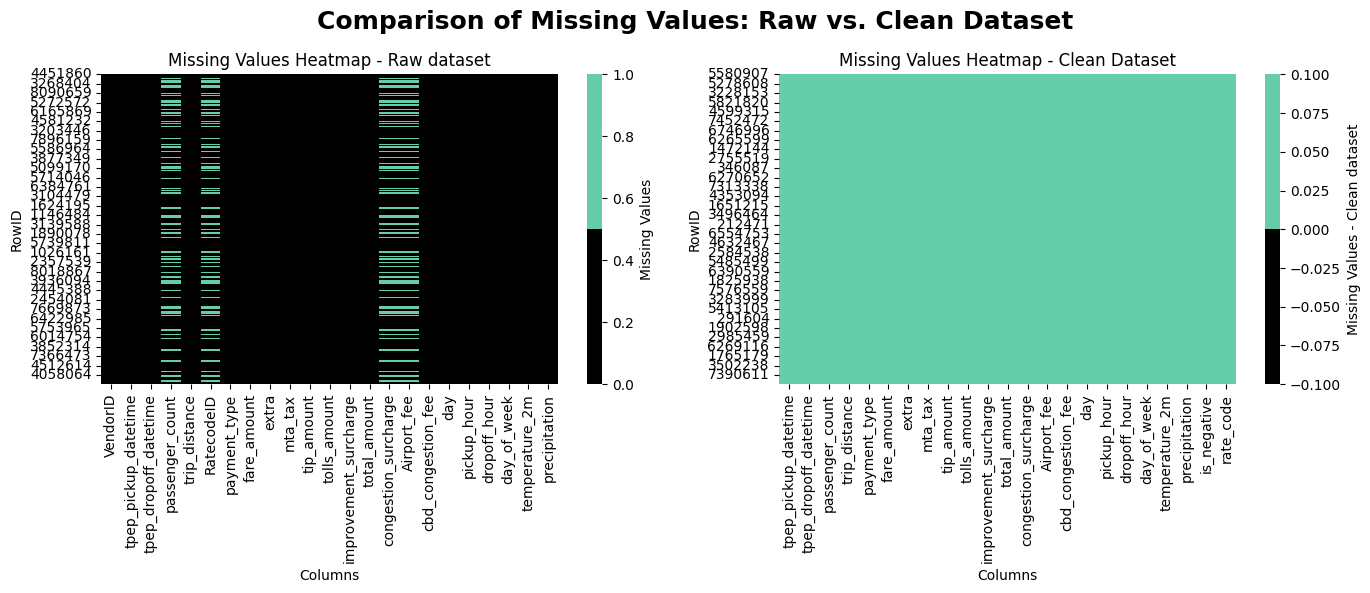

In [30]:
# Display the Before and After Missing Values Heatmap
DataCleaning.display_nan_heatmaps(raw_df, taxi_df)

In [31]:
# Inspect data types
taxi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7683628 entries, 0 to 7683627
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        int8          
 3   trip_distance          float32       
 4   payment_type           category      
 5   fare_amount            float32       
 6   extra                  float32       
 7   mta_tax                float32       
 8   tip_amount             float32       
 9   tolls_amount           float32       
 10  improvement_surcharge  float32       
 11  total_amount           float32       
 12  congestion_surcharge   float32       
 13  Airport_fee            float32       
 14  cbd_congestion_fee     float32       
 15  day                    int8          
 16  pickup_hour            datetime64[us]
 17  dropoff_hour           datetime64[us]
 18  day_of_week           

In [32]:
# Free up memory - Drop temporary variables
del raw_df
%reset -f out
gc.collect()

Flushing output cache (1 entries)


0

### <a name="p1-initial-dda">3.4. Initial DDA: `quantDDA()` and `vizDDA()`</a>

Let's us the methods `quantDDA()` and `vizDDA()` to generate the statistic summary to inspect outliers and verify our data cleaning process, and visualization on `taxi_df`. The functions are implemented in the script `taxi_utils.py` under the class `TaxiDDA()`.

#### <a name="p1-quantDDA">3.4.1. Part 1: `quantDDA()`</a>

In [33]:
dda = TaxiDDA()
dda.quantDDA(taxi_df)

,feature,num_observations,num_entries,num_unique,num_missing,num_outlier,num_extreme,mode,mean,std,min,Q1,median,Q3,max,skew,kurtosis
0,tpep_pickup_datetime,7683628,7683628,3605193,0,nan,nan,2025-06-05T19:27:00.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,tpep_dropoff_datetime,7683628,7683628,3605567,0,nan,nan,2025-06-05T20:02:00.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,passenger_count,7683628,7683628,9,0,1128420,43104,1,1.22,0.64,1,1.0,1.0,1.0,9,3.648,15.498
3,trip_distance,7683628,7683628,5978,0,863850,149220,0.9,7.66,706.34,0.009999999776482582,1.15,2.0,4.0,397994.375,219.599,60052.727
4,payment_type,7683628,7683628,6,0,nan,nan,Credit card,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,fare_amount,7683628,7683628,11810,0,594486,90492,8.6,19.41,117.97,-483.20001220703125,9.3,14.2,23.45,325478.0625,2677.604,7336950.0
6,extra,7683628,7683628,78,0,92930,49983,0.0,1.19,1.82,-7.5,0.0,0.0,2.5,42.459999084472656,1.795,3.611
7,mta_tax,7683628,7683628,64,0,70900,70900,0.5,0.5,1.89,-21.739999771118164,0.5,0.5,0.5,5243.3798828125,2768.556,7671139.0
8,tip_amount,7683628,7683628,5284,0,413814,73427,0.0,2.87,3.94,-8.59000015258789,0.0,2.0,4.0,960.9400024414062,5.96,546.243
9,tolls_amount,7683628,7683628,1418,0,541847,35619,0.0,0.53,2.07,-70.0,0.0,0.0,0.0,716.0499877929688,10.415,1782.039


**Intepretation of Statistical Summary:**
- The dataset still contains negative values for money-value features (see `min`), which is correct and intented. We may need those for future analysis.
- The dataset contains outliers, which will be handled in **Section 3.5 Hanlde Outliers**.
- The dataset contains redundant columns, which will be handled in **Section 3.6 Feature Selection**.

<br>

#### <a name="p1-vizDDA">3.4.2. Part 2: `vizDDA()`</a>
- The full dataset contains **7+ millions of rows** and **22 columns**. While we ran the `quantDDA()` on the entire dataset for statistical accuracy, a full `vizDDA()` would generate a 22x22 grid, making the **visualization overcrowded** and **difficult to interpret**.


- We executed `vizDDA()` on a **smaller sample of 10K entries** using 8 selected columns.

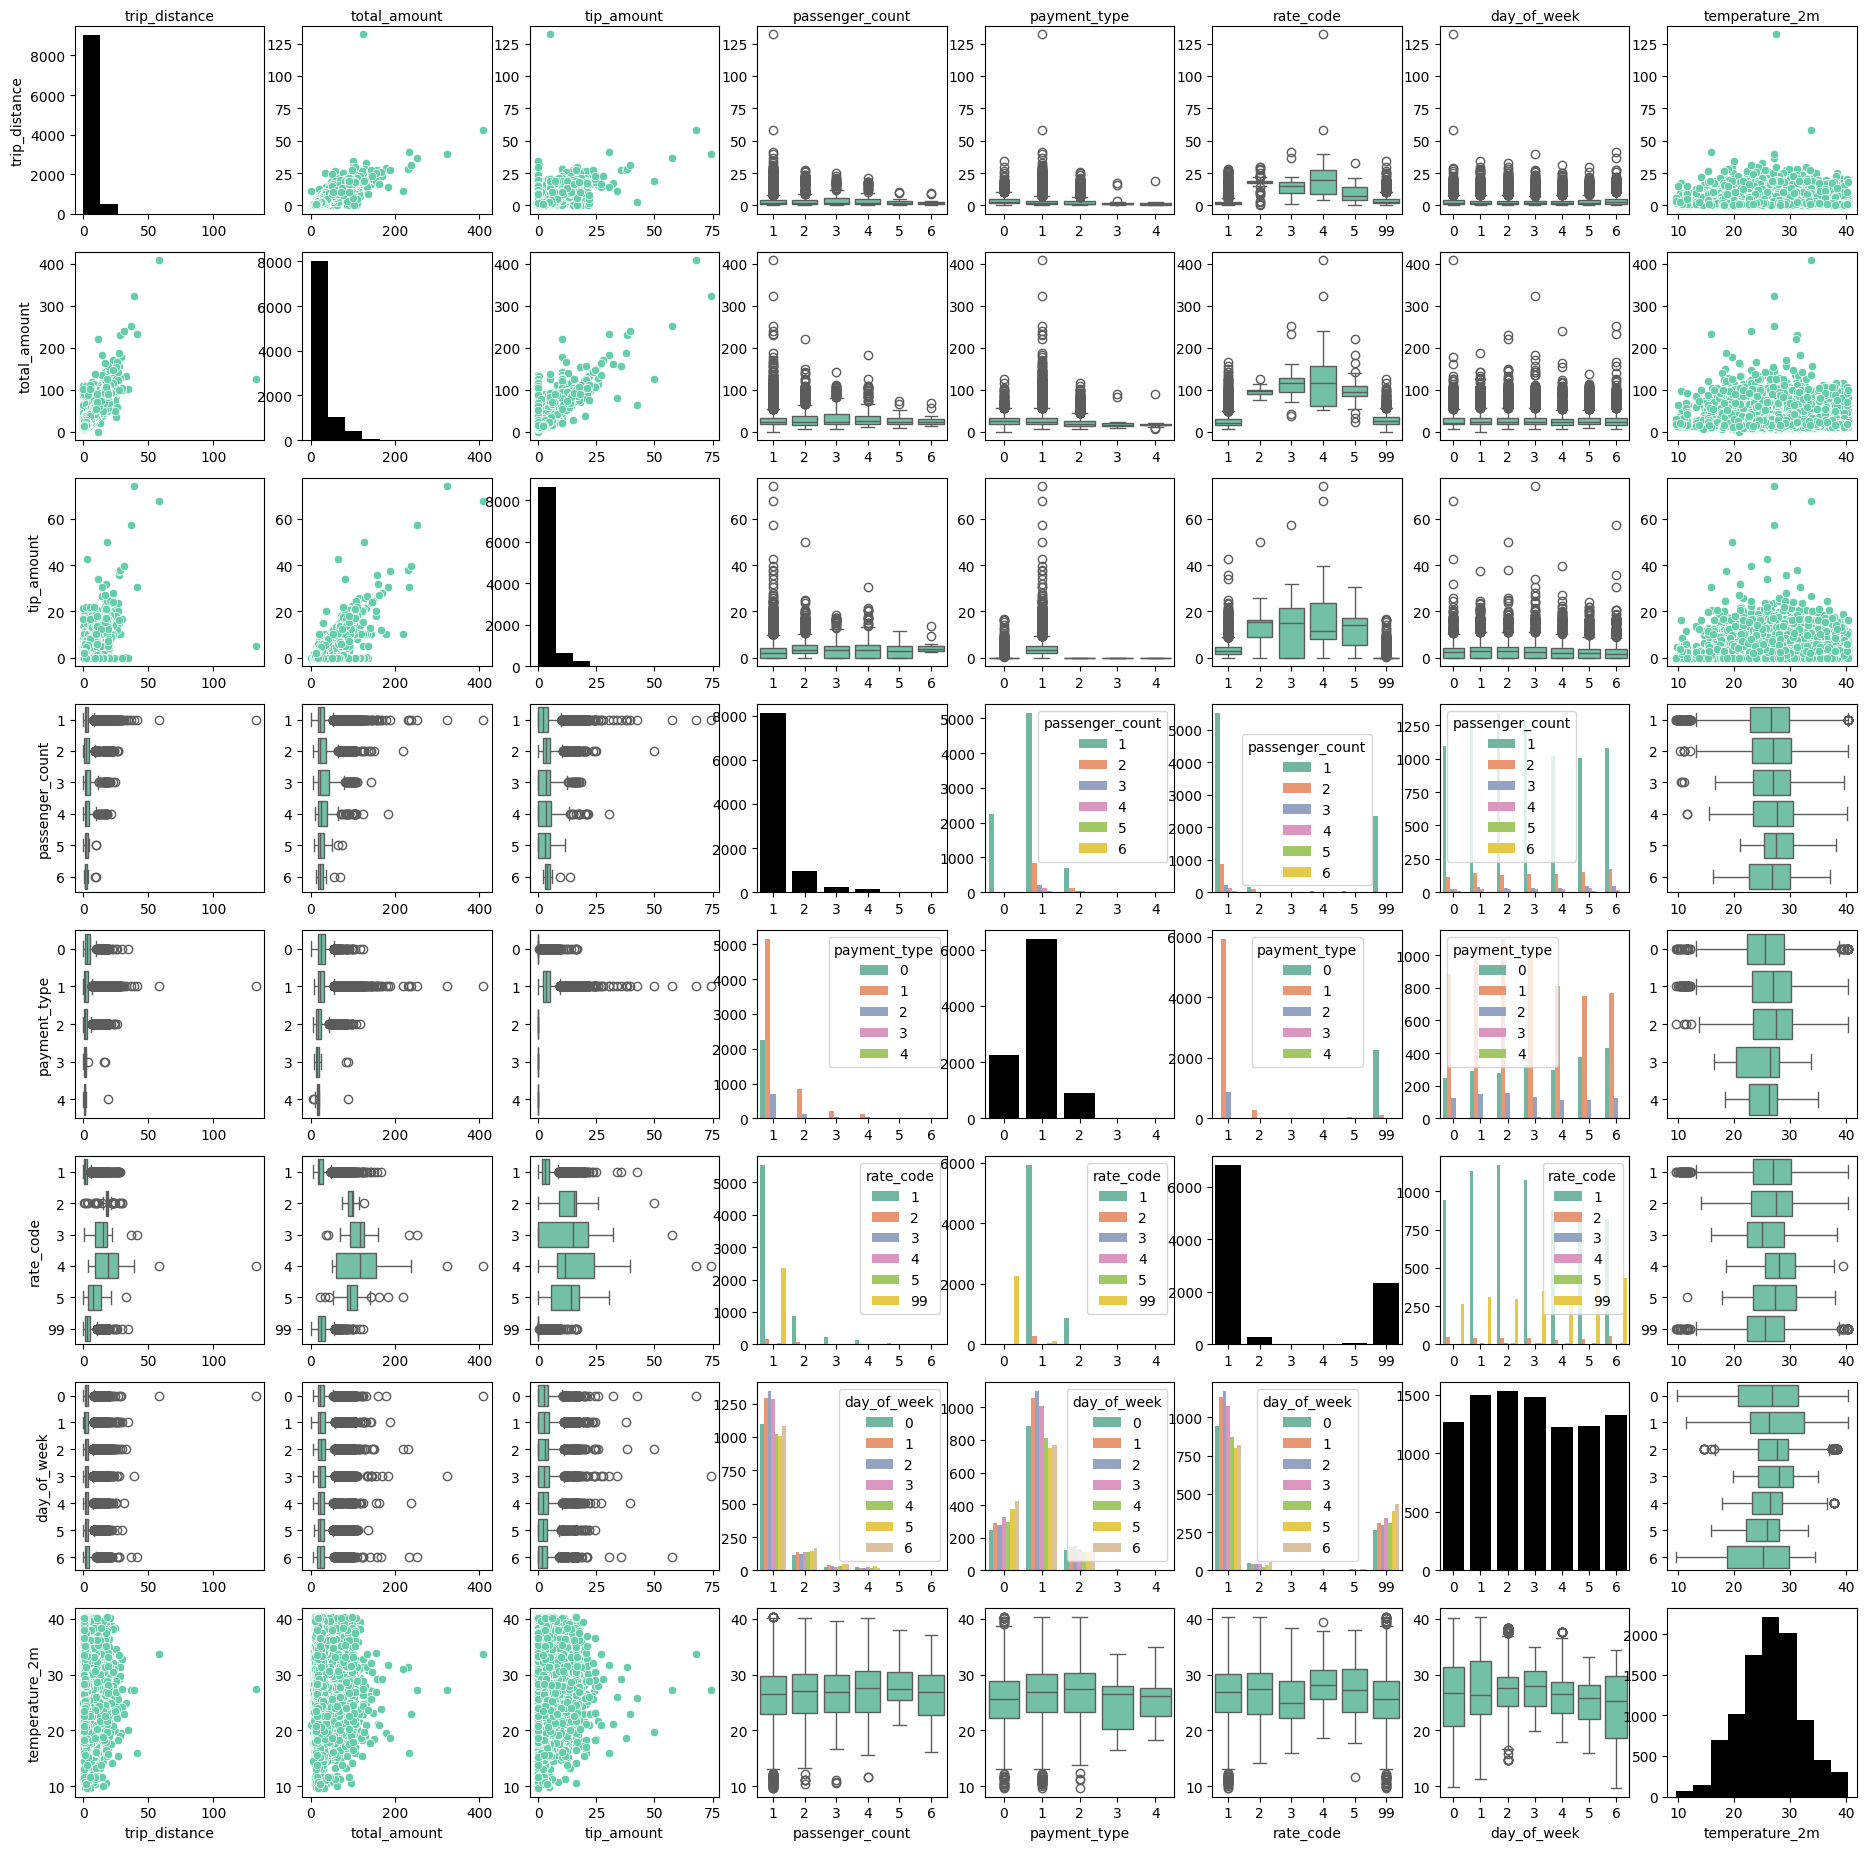

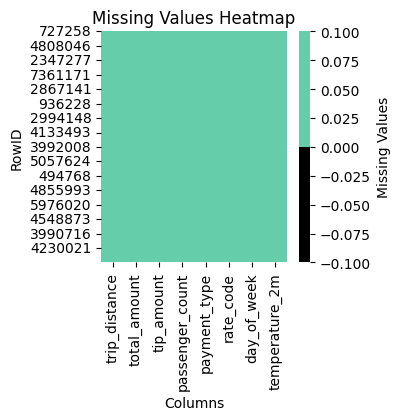

In [34]:
# Randomly sample a batch of 10K entries
sample_df = taxi_df.sample(n=10000, random_state=42)
sample_df = sample_df.loc[~sample_df["is_negative"]]
cols = ["trip_distance", "total_amount", "tip_amount", "passenger_count", "payment_type", "rate_code", "day_of_week", "temperature_2m"]
dda.vizDDA(sample_df[cols])

**Interpretation:**
- The heatmap confirms that the dataset has no more NaN values.
- The `tip_amount` is more likely higher when passenger travels alone, pays by credit card and is going to the airport.
- A greater `trip_distance` is positively correlated with a larger `tip_amount`.
- To prevent clustered visualization, the categorical labels are mapped back to their corresponding numerical codes for `rate_code` and `payment_type`.
- For a detailed visualization analysis, please refer to **Section 4.2 Univariate Visualization** and **Section 4.3 Bivariate Visualization**.

In [35]:
# Free up memory
del sample_df, cols, dda
gc.collect()

6761

### <a name="p1-outliers">3.5. Handle Outliers</a>

The `quantDDA()` summary (Section 3.7) reports IQR-based outliers and extreme values (top/bottom 1%) for each numerical feature. The right-skewed distributions observed in EDA  confirm that `trip_distance`, `fare_amount`, `total_amount`, `tip_amount`, and `tolls_amount` contain extreme high-end values (e.g., trips of 300+ miles or fares of \$1,000+) that are likely data errors or anomalous events.

**Strategy: cap at the 99th percentile (Winsorization)**

We chose *capping* over *dropping* to:
- Preserve the maximum number of rows for model training
- Avoid removing legitimate edge cases (e.g., long airport trips)
- Reduce the statistical influence of erroneous extremes

The **lower bound** is kept at 0 for financial columns (negative values were already addressed by the mirrored-entry removal in Section 3.1).

| Feature | Cap applied |
|---|---|
| `trip_distance` | 99th percentile |
| `fare_amount` | 99th percentile |
| `total_amount` | 99th percentile |
| `tip_amount` | 99th percentile |
| `tolls_amount` | 99th percentile |


In [36]:
# Handle outliers
taxi_df = DataCleaning.handle_outliers(taxi_df)

99th percentile caps:
 trip_distance     19.60
fare_amount       75.10
total_amount     104.03
tip_amount        17.34
tolls_amount       6.94
Name: 0.99, dtype: float64 

Rows above cap (before):
 trip_distance    76448
fare_amount      76455
total_amount     75569
tip_amount       73423
tolls_amount     35540
dtype: int64 

Rows above cap (after):
 trip_distance    0
fare_amount      0
total_amount     0
tip_amount       0
tolls_amount     0
dtype: int64

Dataset shape after capping: 7,683,628 rows × 23 columns


In [37]:
# Free up memory
del DataCleaning
gc.collect()

280132

### <a name="p1-feature-selection">3.6. Feature Selection</a>

We select the features that will be used for the Machine Learning models (RQ1 and RQ2). The raw datetime columns (`tpep_pickup_datetime`, `tpep_dropoff_datetime`, `pickup_hour`, `dropoff_hour`) are dropped since the relevant temporal information has already been extracted into `day`, `day_of_week`, and `hour_of_day`.

**Features kept (14 columns):**

| Feature | Type | Role |
|---|---|---|
| `trip_distance` | float32 | Core trip metric |
| `total_amount` | float32 | Target (RQ1) / cluster feature (RQ2) |
| `tip_amount` | float32 | Behavioral feature |
| `fare_amount` | float32 | Base fare |
| `congestion_surcharge` | float32 | Fee feature |
| `Airport_fee` | float32 | Fee feature |
| `passenger_count` | int8 | Trip attribute |
| `rate_code` | category | Trip category |
| `payment_type` | category | Trip category |
| `day_of_week` | int8 | Temporal feature |
| `day` | int8 | Temporal feature |
| `hour_of_day` | int8 | Temporal feature |
| `temperature_2m` | float32 | Weather feature |
| `precipitation` | float32 | Weather feature |

**Dropped (4 datetime columns):** `tpep_pickup_datetime`, `tpep_dropoff_datetime`, `pickup_hour`, `dropoff_hour`

> **Note for RQ1:** fee subcomponents (`extra`, `mta_tax`, `improvement_surcharge`, `cbd_congestion_fee`, `tolls_amount`, `fare_amount`, `tip_amount`) are components of `total_amount` and will be excluded at model training time to avoid data leakage.


In [38]:
# Extract hour of day as integer before dropping pickup_hour
taxi_df['hour_of_day'] = taxi_df['pickup_hour'].dt.hour.astype('int8')

# Drop raw datetime columns — temporal info already captured in day, day_of_week, hour_of_day
cols_to_drop = [
    'tpep_pickup_datetime',   # replaced by day, day_of_week, hour_of_day
    'tpep_dropoff_datetime',  # trip duration not computed for Phase 1
    'dropoff_hour',           # datetime used only for weather merge
]
taxi_df = taxi_df.drop(columns=cols_to_drop)

# Free up memory
del cols_to_drop
gc.collect()

print(f"Final shape: {taxi_df.shape[0]:,} rows × {taxi_df.shape[1]} columns")
taxi_df.dtypes


Final shape: 7,683,628 rows × 21 columns


,0
passenger_count,int8
trip_distance,float32
payment_type,category
fare_amount,float32
extra,float32
mta_tax,float32
tip_amount,float32
tolls_amount,float32
improvement_surcharge,float32
total_amount,float32


**Publish our cleaned dataset**

In [39]:
# Save the final feature-selected dataset

taxi_df.to_parquet('taxi_cleaned.parquet', index=False)
print("Saved to taxi_cleaned.parquet")

Saved to taxi_cleaned.parquet


## <a name="p1-eda">4.Exploratory Data Analysis (EDA)</a>
___

### <a name="p1-summary">4.1. Summary Statistics</a>

The following shows the summary statistics of the entire dataset.

In [40]:
eda = TaxiEDA()
eda.summary_stats(taxi_df)

Dataset shape: 7,683,628 rows × 21 columns



,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,passenger_count
count,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00
mean,3.55,19.08,1.19,0.50,2.81,0.48,0.99,27.81,1.67,0.12,0.56,1.22
std,4.05,15.91,1.82,1.89,3.59,1.72,0.12,19.78,1.18,0.45,0.34,0.64
min,0.01,-483.20,-7.50,-21.74,-8.59,-70.00,-1.00,-441.45,-2.50,-1.75,-0.75,1.00
25%,1.15,9.30,0.00,0.50,0.00,0.00,1.00,16.35,0.00,0.00,0.00,1.00
50%,2.00,14.20,0.00,0.50,2.00,0.00,1.00,21.90,2.50,0.00,0.75,1.00
75%,4.00,23.45,2.50,0.50,4.00,0.00,1.00,31.22,2.50,0.00,0.75,1.00
max,19.60,75.10,42.46,5243.38,17.34,6.94,1.00,104.03,2.50,6.75,1.50,9.00


### <a name="p1-univariate">4.2. Univariate Visualizations</a>

The following plots show the individual distribution of each key feature:
1. **Trip Distance** — right-skewed; most trips are short (under 5 miles)
2. **Total Amount** — right-skewed; majority of fares are under $40

3. **Tip Amount** — heavily right-skewed; many trips have $0 tip (cash payments)

4. **Passenger Count** — majority are single-passenger trips
5. **Payment Type** — credit card is the dominant payment method
6. **Rate Code** — standard rate (1) dominates; a small proportion are airport trips
7. **Day of Week** — relatively uniform; slight dip on Sundays
8. **Temperature** — bimodal reflecting June/July seasonal variation in NYC

<br>

**NOTE:** The visualization is executed on a representative random sample of 10K entries.

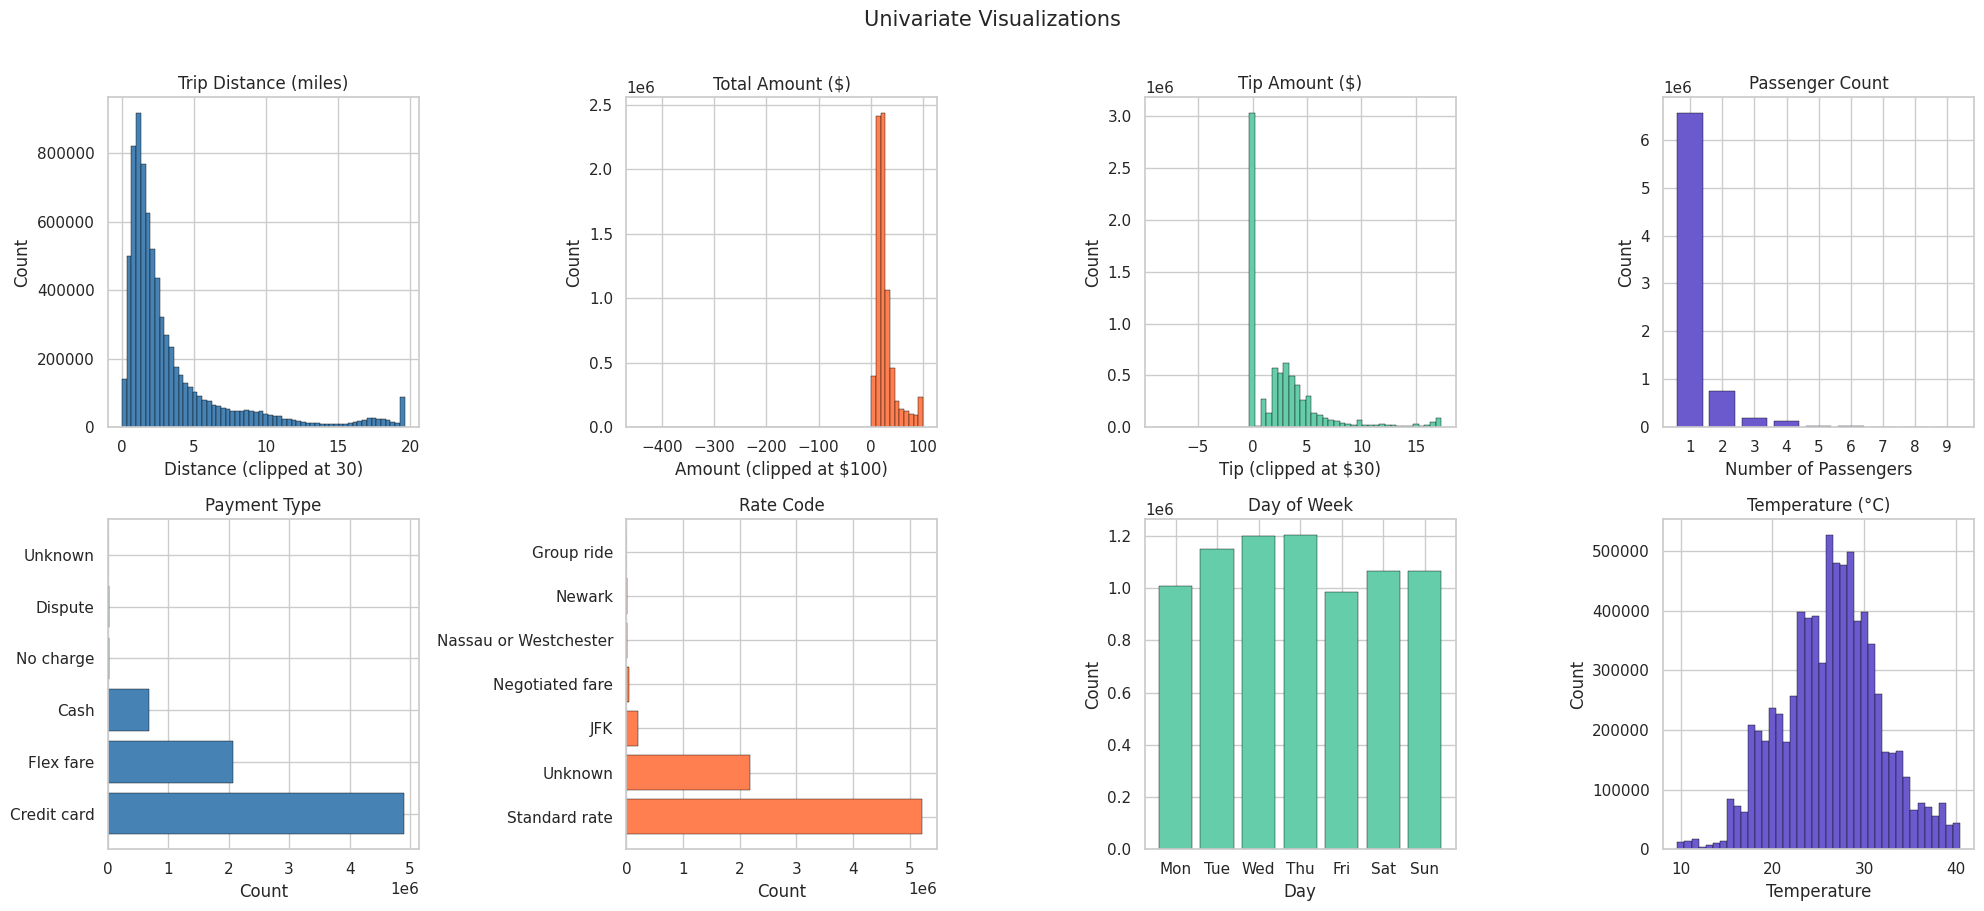

In [41]:
eda.plot_univariate(taxi_df)

### <a name="p1-bivariate">4.3. Bivariate Visualizations</a>

The following plots explore relationships between pairs of features:
1. **Trip Distance vs Total Amount** — expected positive linear relationship
2. **Total Amount by Payment Type** — how payment method relates to fare value
3. **Total Amount by Rate Code** — fare differences across rate categories (e.g., airport trips)
4. **Trip Volume by Hour of Day** — demand patterns across the day (higher demands after 17h, lower demands during early mornings).
5. **Trip Distance vs Tip Amount** — longer trips attract higher tips
6. **Temperature vs Average Total Amount** — weather conditions affect fare


<br>

**NOTE:** The visualization is executed on a representative random sample of 10K entries.

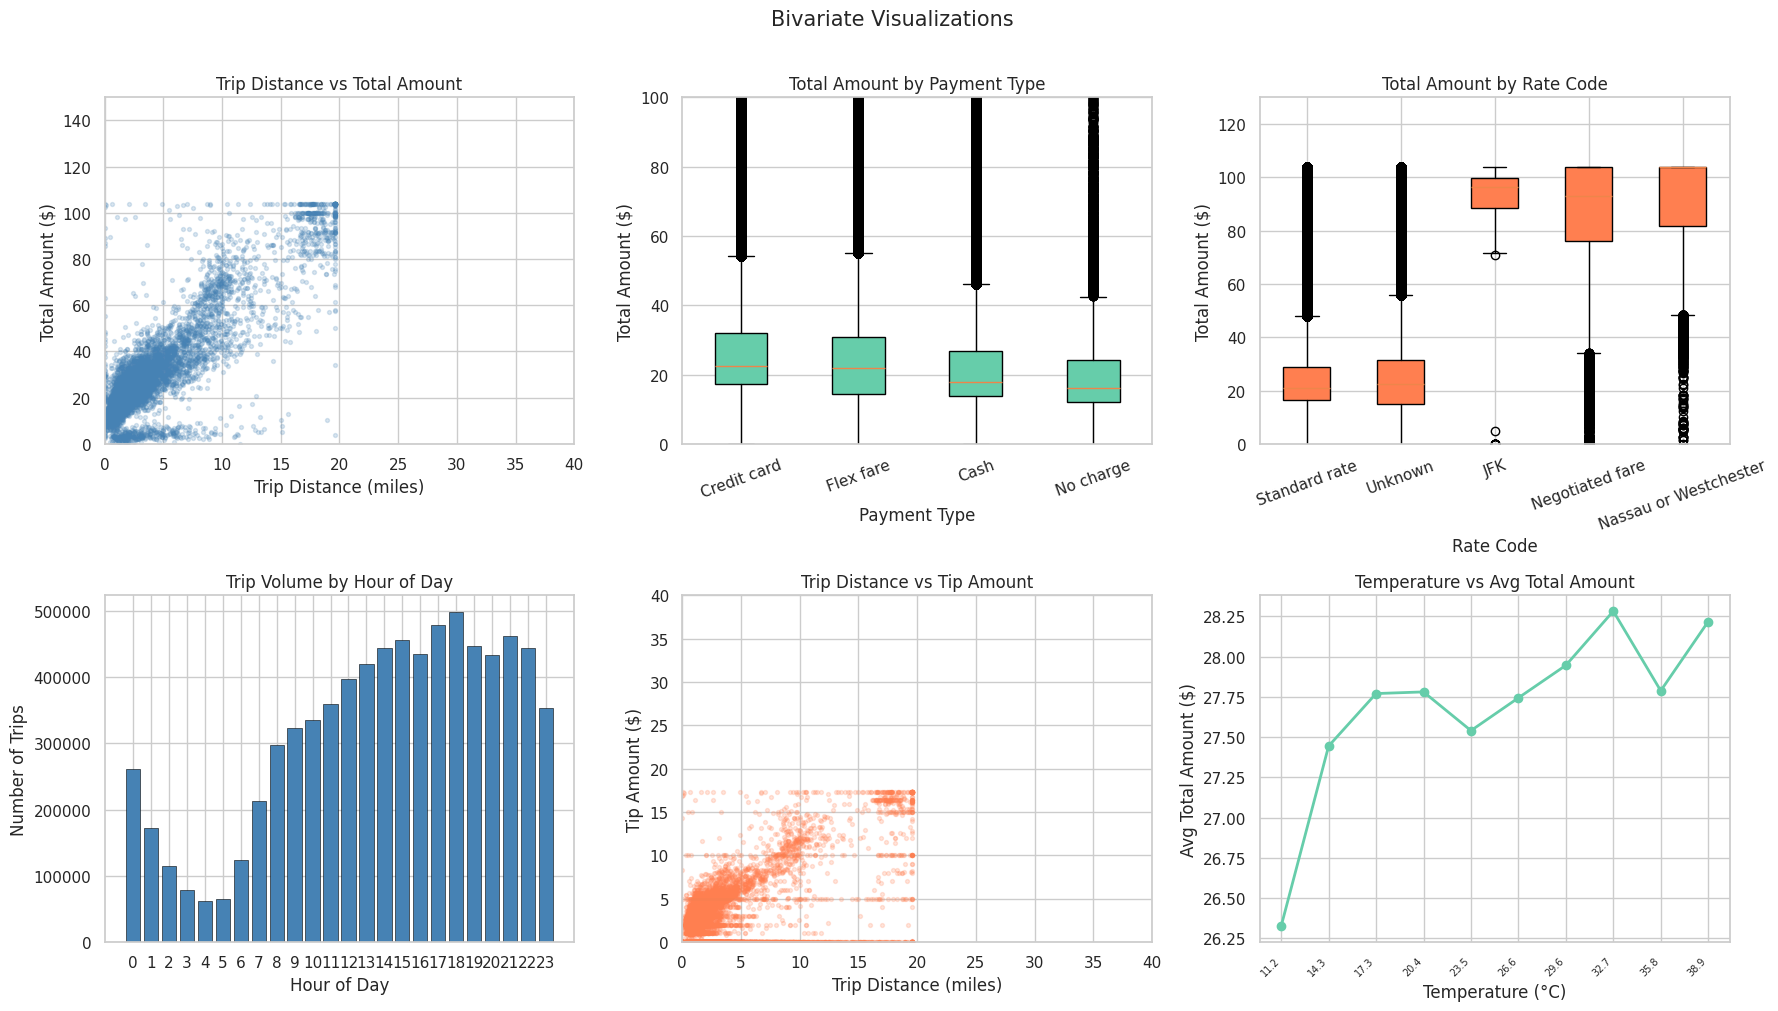

In [42]:
eda.plot_bivariate(taxi_df)

### <a name="p1-correlation">4.4. Correlation Analysis</a>

The heatmap below shows pairwise Pearson correlations between all numerical features. Stronger positive correlations (red) indicate features that tend to increase together, while negative correlations (blue) indicate inverse relationships.

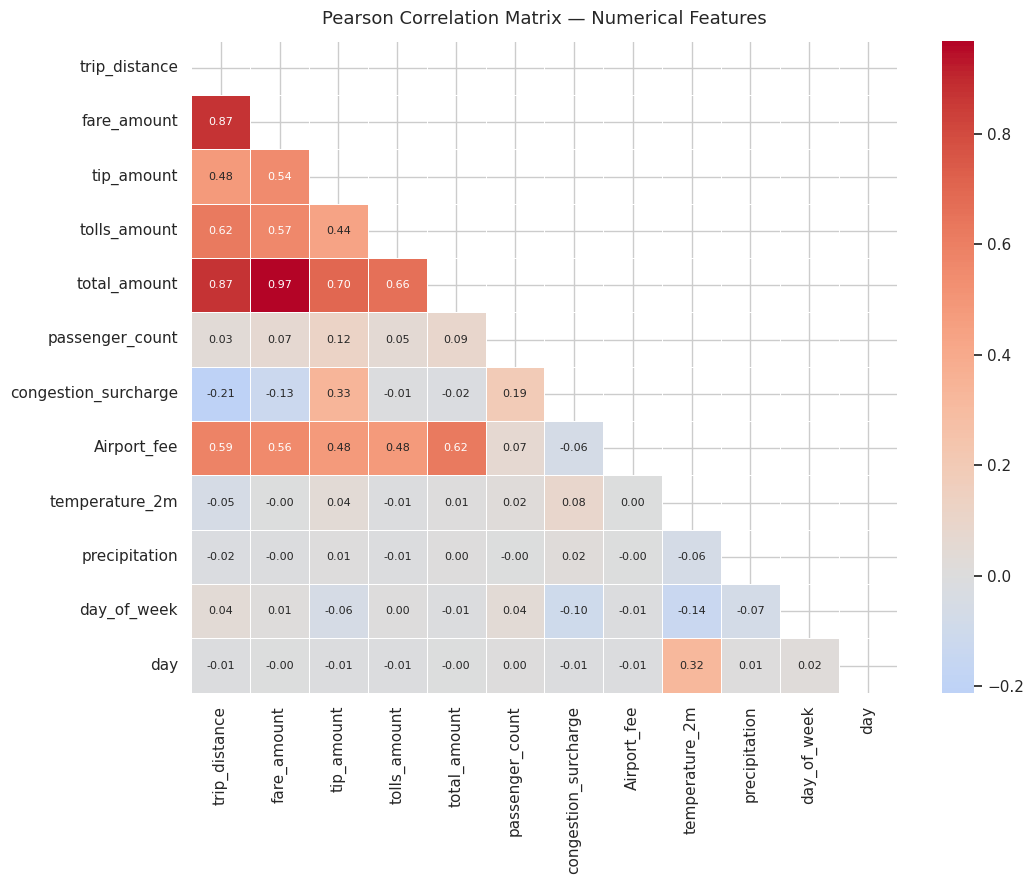

In [43]:
eda.plot_correlation(taxi_df)

### <a name="p1-research-questions">4.5. Research Questions</a>

Based on the exploratory analysis above, we formulate the following two research questions:

---

**RQ1 — Supervised Learning:**
> *"Can we classify a high-tipper passenger based on trip-selected features (distance, time of day, day of week, rate code, passenger count) and weather conditions (temperature, precipitation)?"*

- **Type:** Classification
- **Models:** XGBoost and Random Forest
- **Target variable:** `is_high_tip` (Boolean: 1 if tip>20% of the fare amount, 0 otherwise)
- **Features:** `trip_distance`, `pickup_hour` (as hour-of-day), `day_of_week`, `passenger_count`, `temperature_2m`, `precipitation`
- **Motivation:** In Phase 1 Section 5, we are already focusing on training a baseline regression model to predict the continuous variable `fare_amount`. For Supervised Learning in Phase 2, we are moving to a binary classification problem to understand the tipping behaviour of NYC yellow taxi customers. We will transform `tip_amount` feature into a binary feature `is_high_tip` through feature engineering. By using **XGBoost** and **Random Forest**, we will analyze which factors most significantly influence customers tipping behaviour, such as poor weather conditions, late-night trips, weekend travel, etc. This provide valuable insights for optimizing driver service and maximizing incomes.

---

**RQ2 — Unsupervised Learning:**
> *"Can we identify the distinct natural clusters of NYC taxi trips based on their temporal, financial to study customer behavior?"*

- **Type:** Clustering (K-Means)
- **Features:** `trip_distance`, `total_amount`, `tip_amount`, `pickup_hour` (as hour-of-day), `day_of_week`, `passenger_count`, `temperature_2m`, `precipitation`
- **Motivation:** The bivariate and correlation analysis reveal non-uniform distributions and potential sub-populations (e.g., airport trips, short city hops, late-night rides). Clustering will help characterize distinct rider archetypes and trip patterns, which can inform targeted services and policy decisions.

<br>

## <a name="p1-baseline">5.Baseline Model</a>
___

We will do a comparison of three Linear Regression models for target feature `fare_amount`:
- **Model 1** will use only 1 input: `trip_distance`
- **Model 2** will use 2 inputs: `trip_distance` and `tip_amount`
- **Model 3** will use 3 inputs: `trip_distance`, `tip_amount` and `Airport_fee`
<br>

We chose `trip_distance` as our main predictive feature because its pearson correlation coefficient with our target `fare_amount` is the highest among features that are not dependant on the target, at 0.87. This shows a strong positive relationship, perfect for linear regression. Our other predictive features, `airport_fee` and `tip_amount`, were chosen because of their non-negligible pearson correlation coefficients of 0.56 and 0.54, respectively. Our goal with those three models is to see if our target is better predicted with `trip_distance` alone, or if it predicts better with the aid of one or two other correlated features.

However, we must first do a bit of additional data wrangling.
- **Reason 1:** Some rows show negative fares, likely due to refunds or system adjustments. We want to keep these records because their other features (like distance and time) are still valid for our general analysis.
- **Reason 2:** To avoid skewing our linear regression model, we filtered out these rows to exclude them from the training data.

As such, before we transfer our data to a numpy array, we will drop all rows that have a negative fare amount.


In [44]:
# First, create a sample dataframe that takes 10,000 rows from those where is_negative is False
regression_sample_df = taxi_df[taxi_df['is_negative'] == False].sample(n=10000, random_state=1)

# Create numpy arrays for our feature X and target Y
X = regression_sample_df[['trip_distance', 'tip_amount', 'Airport_fee']].to_numpy()
Y= regression_sample_df['fare_amount'].to_numpy()

### 5.1. Splitting Phase

We use the `train_test_split` function twice.
- First split to get a 15 % **Testing set** of the entire dataset (by setting the test dataset's size to 0.15)
- Another split to create a **Validation dataset** and a **Training dataset**. We pulled out 15% Validation of the original data from the remaining 85% of the chunk.

This gives us a 70%/15%/15% split of the data for training, testing and validation.

In [45]:
# 1. Get the 15% Testing set (by setting test_size=0.15)
x_temp, x_test, y_temp, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)

# 2. Get 15% Validation set from the remaining 85% portion
# Training + Validation = temp = Remaining 85%
valid_ratio = 0.15 / 0.85
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=valid_ratio, random_state=1)

# Check
print(f"Train set: {len(x_train)/len(X):.1%}")
print(f"Valid set: {len(x_valid)/len(X):.1%}")
print(f"Test set:  {len(x_test)/len(X):.1%}")


Train set: 70.0%
Valid set: 15.0%
Test set:  15.0%


### 5.2. Training Phase

Now, we train our 3 models.

In [46]:
models = lr_model.train_models(x_train, y_train, x_valid, y_valid)

### 5.3. Validation Phase

**Performance metrics:** We will use two metrics: MSE and $R^2$.
- **Mean Squared Errors (MSE)** is the objective function (loss) which measures how far the predictions are from the targeted ones. A good model has the lowest MSE.
- **$R^2$** is a statistical metric to measure how well our model "fits" the data. A good model has the highest $R^2$.

- We compute these two metrics for **models 1, 2 and 3** on the **validation set** to **compare model perfomance**.

In [47]:
for name, model in models.items():
    print(f"MSE for {name}: {model['MSE']:.4f}")
    print(f"R2 for {name}: {model['R2']:.4f}\n")

MSE for model_1: 29.4493
R2 for model_1: 0.8811

MSE for model_2: 28.4416
R2 for model_2: 0.8852

MSE for model_3: 28.5251
R2 for model_3: 0.8849



**Model Performance:**
- The three models give very similar Mean Squared Errors (MSE) and $R^2$, with minor differences in the decimals.
- **Model 2** has the lowest MSE and the highest $R^2$.
- **Model Selection:** For Phase 1, we selected **Model 2** as our baseline model.
  1. It has the **lowest MSE** and a **higher $R^2$**.
  2. It provides **higher interpretability** than Model 3, while also being more complex and thus giving a better idea of the relationship between features than Model 1.

### 5.4. Testing Phase

In [48]:
model_2 = models['model_2']['lr']
test_predict = model_2.predict(x_test[:, :2])
print(f"MSE on test for model 2: {mean_squared_error(y_test, test_predict):.4f}")
print(f"R2 on test for model 2: {model_2.score(x_test[:, :2], y_test):.4f}")

MSE on test for model 2: 36.4747
R2 on test for model 2: 0.8614


On the test set, model 2 shows slightly worst MSE and $R^2$ scores to those in the validation, which is most likely due to natural differences in two randomly separated 15% samples of a larger set. This does mean that model 2 performs slightly worse on the unseen test data.
- This indicates that the combination of `trip_distance` and `tip_amount` gives better predictions for `fare_amount` than other configurations (`trip_distance` alone, or both with `Airport_fee` added).

- We visualize the model using a scatter plot and a regression line: $y = a1x1 +a2x1 + b$
- $a1$, $a2$ represent the coefficients (weights) for $x_1$ = `trip_distance` and $x_2$ = `tip_amount` respectively.
- $b$ represents the intercept (bias).
- Since our model uses **two features for X**, we show their relationship with the target through two 2D plots, each using the x values and the model's coefficient for one of the features.

Bias: 7.169
Coefficient a1: 3.359
Coefficient a2: 0.350
Equation for Linear Regression model 2: y =  3.359 x_1 +  0.350 x_2 + 7.169


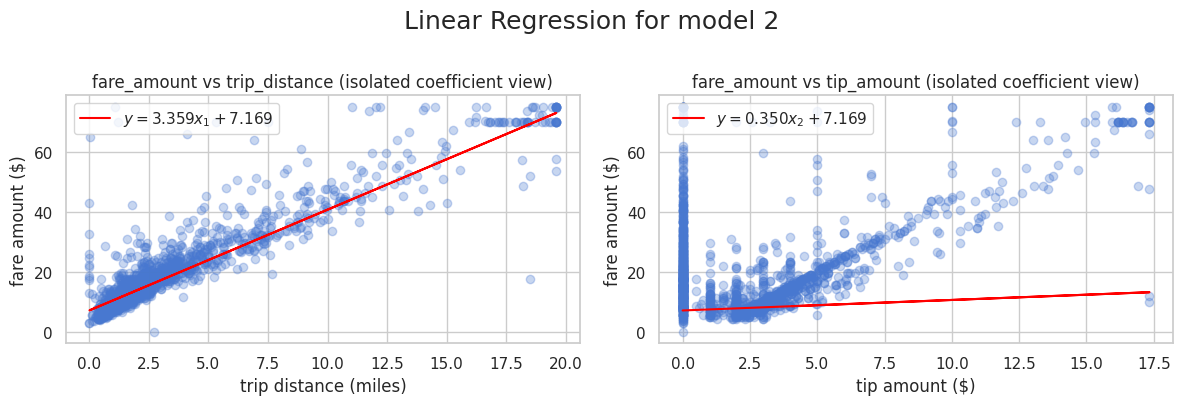

In [49]:
lr_model.visualiser(model_2, 'model 2',
                    x_test, y_test,
                    'fare_amount', ['trip_distance', 'tip_amount'],
                    y_label='fare amount ($)',
                    x_labels=['trip distance (miles)', 'tip amount ($)'])

**Interpretation:**
- The `trip distance` and the `fare amount`'s growths seem to be highly correlated.
- The comparison between `tip amount` and `fare amount` show significantly higher variance.
- The spread of `tip amount` data shows that `tip_amount` is a **weaker predictor** than `trip distance`.
- The high frequency of zero values in the `tip amount` (likely due to cash transactions) motivates a ***further investigation*** into tip distributions across different payment types.
- The trend line for `trip distance` fits the majority of the sample points, suggesting it is the primary driver behind Model 2's performance.
- While the `tip amount` trend line appears faulty, its inclusion likely influenced the model, allowing `trip distance` to align more closely with the overall data trend.
- **Model 2** is a useful baseline for `taxi_df`. It confirms that trip distance has a measurable impact on the fare amount.

<br>

**Clean Up Memory**

In [50]:
# Free up memory by deleting temporary variables
del (LinearRegression, TaxiDDA, TaxiEDA, X, Y, eda, lr_model, math,
     mean_squared_error, model, model_2, models, name, np, pd, plt, regression_sample_df,
     taxi_df, test_predict, train_test_split, valid_ratio, x_temp, x_test, x_train, x_valid, y_temp,
     y_test, y_train, y_valid)

%reset -f out
gc.collect()

Flushing output cache (6 entries)


0

___
___

# <a name="Phase-2">B.Project Phase 2 — Advanced Modeling</a>

### **Task Description**
Phase 2 of this project involves the following steps:
1. Perform feature engineering to optimize model performance.
2. Implement two advanced supervised machine learning classifiers (XGBoost and Random Forest); analyze and compare performance.
3. Implement an unsupervised machine learning model (K-Means) and evaluate its quality.
4. Interpret results to answer the research questions from Section A.

<br><br>

### **Division-of-Labour Statement**
See [Divison-of-Labour](#division-labor) in the header.

<br>

## <a name="p2-libraries">6.Import Libraries</a>

In [51]:
# For machine learning models
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, silhouette_score, confusion_matrix, f1_score, classification_report,
                             roc_curve, davies_bouldin_score, calinski_harabasz_score)

# Refactor code for Supervised Learning
from model_evaluation import Evaluator
from feature_selection import FeatureSelector
from kmeans_utils import kmeans_utils

# General libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import gc
import time

**After restarting the session**, let's manually import the cleaned dataset `taxi_cleaned.parquet` to proceed.

**Note**: Please re-run this cell if it throws an error. Temporary file locks may cause an initial failure.

In [52]:
# Read dataset
time.sleep(2)
taxi_df = pd.read_parquet('taxi_cleaned.parquet')

## <a name="p2-feature-engineering">7.Feature Engineering</a>
____
This section involves:
1. Engineering new features to optimize model performance.
2. Performing feature selection.

In [53]:
# Create a boolean is_high_tip feature based on the percentage of the total amount that is determined by the tip
taxi_df['is_high_tip'] = taxi_df['tip_amount'] >= taxi_df['fare_amount'] * 0.2

# Create fare based and tip based features that are independent of trip distance
taxi_df['log_fare_per_km'] = np.log(np.maximum(taxi_df['fare_amount'], 0) / np.maximum(taxi_df['trip_distance'], 0.5) + 1)
taxi_df['tip_ratio'] = np.log(np.maximum(taxi_df['tip_amount'], 0) / np.maximum(taxi_df ['fare_amount'], 1) + 1)
taxi_df['log_trip_distance'] = np.log(taxi_df ['trip_distance'] + 1)

In [54]:
# Ensure hour_of_day exists (may be missing if Phase 1 did not complete fully)
if 'hour_of_day' not in taxi_df.columns:
    taxi_df['hour_of_day'] = taxi_df['pickup_hour'].dt.hour.astype('int8')

# Hour of day as a sine/cosine cycle
taxi_df['hour_sin'] = np.sin(2 * np.pi * taxi_df['hour_of_day'] / 24)
taxi_df['hour_cos'] = np.cos(2 * np.pi * taxi_df['hour_of_day'] / 24)

# Day of week as a sine/cosine cycle
taxi_df['day_sin'] = np.sin(2 * np.pi * taxi_df['day_of_week'] / 7)
taxi_df['day_cos'] = np.cos(2 * np.pi * taxi_df['day_of_week'] / 7)


### 7.1. Time-Based & Log Feature
| Feature | Description |
|---------|-------------|
| `is_high_tip` | **Target for RQ1** — `True` if tip ≥ 20 % of base fare (`fare_amount`) |
| `log_trip_distance` | Log-transform of distance to reduce right-skew |
| `log_fare_per_km` | Log-scaled fare efficiency |
| `tip_ratio` | Log-scaled tip-to-fare ratio *(excluded from feature selection — leakage risk)* |

The cell above extends these with **cyclical time encodings**:

| Feature | Description |
|---------|-------------|
| `hour_sin/cos` | Cyclical encoding of hour (23 h stays close to 0 h) |
| `day_sin/cos` | Cyclical encoding of day of week |

### 7.2. Domain-Specific Features

Features derived from NYC taxi domain knowledge:

| Feature | Motivation |
|---------|------------|
| `is_rush_hour` | Weekday 7–9 AM or 5–7 PM — high demand may affect tipping |
| `is_weekend` | Saturday / Sunday ride patterns differ from weekdays |
| `is_night` | 10 PM – 5 AM — night surcharges apply |
| `is_airport` | JFK or Newark flat-rate trip |
| `fare_per_mile` | Cost efficiency of the trip (capped at 99th percentile) |
| `is_credit_card` | Cash tips are **not digitally recorded** → structural zero for cash payments |

In [55]:
# 1. Rush hour: weekday 7–9 AM or 5–7 PM
taxi_df['is_rush_hour'] = (
    (taxi_df['hour_of_day'].between(7, 9) | taxi_df['hour_of_day'].between(17, 19)) &
    (taxi_df['day_of_week'] < 5)
).astype('int8')

# 2. Weekend
taxi_df['is_weekend'] = (taxi_df['day_of_week'] >= 5).astype('int8')

# 3. Night ride (10 PM – 5 AM)
taxi_df['is_night'] = (
    (taxi_df['hour_of_day'] >= 22) | (taxi_df['hour_of_day'] <= 5)
).astype('int8')

# 4. Airport trip (JFK or Newark flat-rate)
taxi_df['is_airport'] = taxi_df['rate_code'].isin(['JFK', 'Newark']).astype('int8')

# 5. Fare per mile — cap at 99th percentile of positive-fare trips
_cap = (
    taxi_df.loc[taxi_df['fare_amount'] > 0, 'fare_amount'] /
    taxi_df.loc[taxi_df['fare_amount'] > 0, 'trip_distance']
).quantile(0.99)
taxi_df['fare_per_mile'] = (
    (taxi_df['fare_amount'] / taxi_df['trip_distance']).clip(lower=0, upper=_cap)
).astype('float32')
del _cap

# 6. Credit card flag
taxi_df['is_credit_card'] = (taxi_df['payment_type'] == 'Credit card').astype('int8')

print('Domain features added:')
print(taxi_df[['is_rush_hour','is_weekend','is_night',
               'is_airport','fare_per_mile','is_credit_card']].describe().round(3))

Domain features added:
       is_rush_hour   is_weekend     is_night   is_airport  fare_per_mile  \
count   7683628.000  7683628.000  7683628.000  7683628.000    7683628.000   
mean          0.228        0.277        0.202        0.029          7.703   
std           0.419        0.448        0.402        0.167          4.756   
min           0.000        0.000        0.000        0.000          0.000   
25%           0.000        0.000        0.000        0.000          5.221   
50%           0.000        0.000        0.000        0.000          6.940   
75%           0.000        1.000        0.000        0.000          9.028   
max           1.000        1.000        1.000        1.000         37.000   

       is_credit_card  
count     7683628.000  
mean            0.638  
std             0.481  
min             0.000  
25%             0.000  
50%             1.000  
75%             1.000  
max             1.000  


### 7.3. Polynomial & Interaction Features

| Feature | Description |
|--------|-------------|
| **trip_distance_sq** | Distance² — fare grows non-linearly on very long trips |
| **distance_x_passengers** | Distance × passenger count — group trips cost more overall |
| **temp_x_precipitation** | Temperature × precipitation — combined bad-weather effect on tipping |


In [56]:
taxi_df['trip_distance_sq']       = (taxi_df['trip_distance'] ** 2).astype('float32')
taxi_df['distance_x_passengers']  = (taxi_df['trip_distance'] * taxi_df['passenger_count']).astype('float32')
taxi_df['temp_x_precipitation']   = (taxi_df['temperature_2m'] * taxi_df['precipitation']).astype('float32')

print(f'Polynomial/interaction features added.')
print(f'taxi_df now has {taxi_df.shape[1]} columns total.')

Polynomial/interaction features added.
taxi_df now has 38 columns total.


### 7.4. Feature Selection

We apply three complementary approaches to find the best features for predicting `is_high_tip`:

1. **Filter methods** score features without training a model  
   - Variance threshold: drop near constant features  
   - Pearson correlation: linear relationship with the target  
   - Mutual information: captures non-linear dependencies  
2. **Embedded method** importance scores from a trained Random Forest  
3. **Wrapper method**  Recursive Feature Elimination (RFE) with Logistic Regression  

> **Leakage note:** `tip_amount`, `total_amount`, and `tip_ratio` are excluded  
> they are derived from the same quantity as the target `is_high_tip`.

#### 7.4.1. Setup Feature Matrix & Target

In [57]:
# All engineered features — leaky columns excluded
FEATURE_COLS = [
    # Raw numerical
    'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount',
    'improvement_surcharge', 'congestion_surcharge', 'Airport_fee',
    'cbd_congestion_fee', 'passenger_count', 'temperature_2m', 'precipitation',
    'hour_of_day', 'day_of_week', 'day',
    # Log / ratio
    'log_trip_distance', 'log_fare_per_km', 'fare_per_mile',
    # Cyclical time
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    # Domain-specific
    'is_rush_hour', 'is_weekend', 'is_night', 'is_airport', 'is_credit_card',
    # Polynomial & interaction
    'trip_distance_sq', 'distance_x_passengers', 'temp_x_precipitation',
]
TARGET = 'is_high_tip'

# Use only positive-fare trips; drop any remaining NaNs
feat_df = taxi_df[taxi_df['is_negative'] == False][FEATURE_COLS + [TARGET]].dropna()

# 50 000-row sample keeps selection fast
sample = feat_df.sample(n=50_000, random_state=42)
X_all  = sample[FEATURE_COLS].values.astype('float32')
y      = sample[TARGET].astype(int).values

print(f'Feature matrix : {X_all.shape[0]:,} samples x {X_all.shape[1]} features')
print(f'Class balance  : is_high_tip = 1  ->  {y.mean()*100:.1f} %')

Feature matrix : 50,000 samples x 30 features
Class balance  : is_high_tip = 1  ->  50.4 %


#### 7.4.2. Filter Methods

Low-variance features removed: ['mta_tax']
Top 10 — Mutual Information:
is_credit_card           0.2803
fare_amount              0.1832
congestion_surcharge     0.1486
log_fare_per_km          0.0689
fare_per_mile            0.0682
extra                    0.0484
trip_distance            0.0284
log_trip_distance        0.0278
trip_distance_sq         0.0250
distance_x_passengers    0.0199

Top 10 — Pearson Correlation:
is_credit_card           0.6784
congestion_surcharge     0.5095
extra                    0.2450
log_trip_distance        0.1404
improvement_surcharge    0.1218
is_night                 0.1063
fare_amount              0.1050
passenger_count          0.1003
trip_distance            0.0893
hour_sin                 0.0889


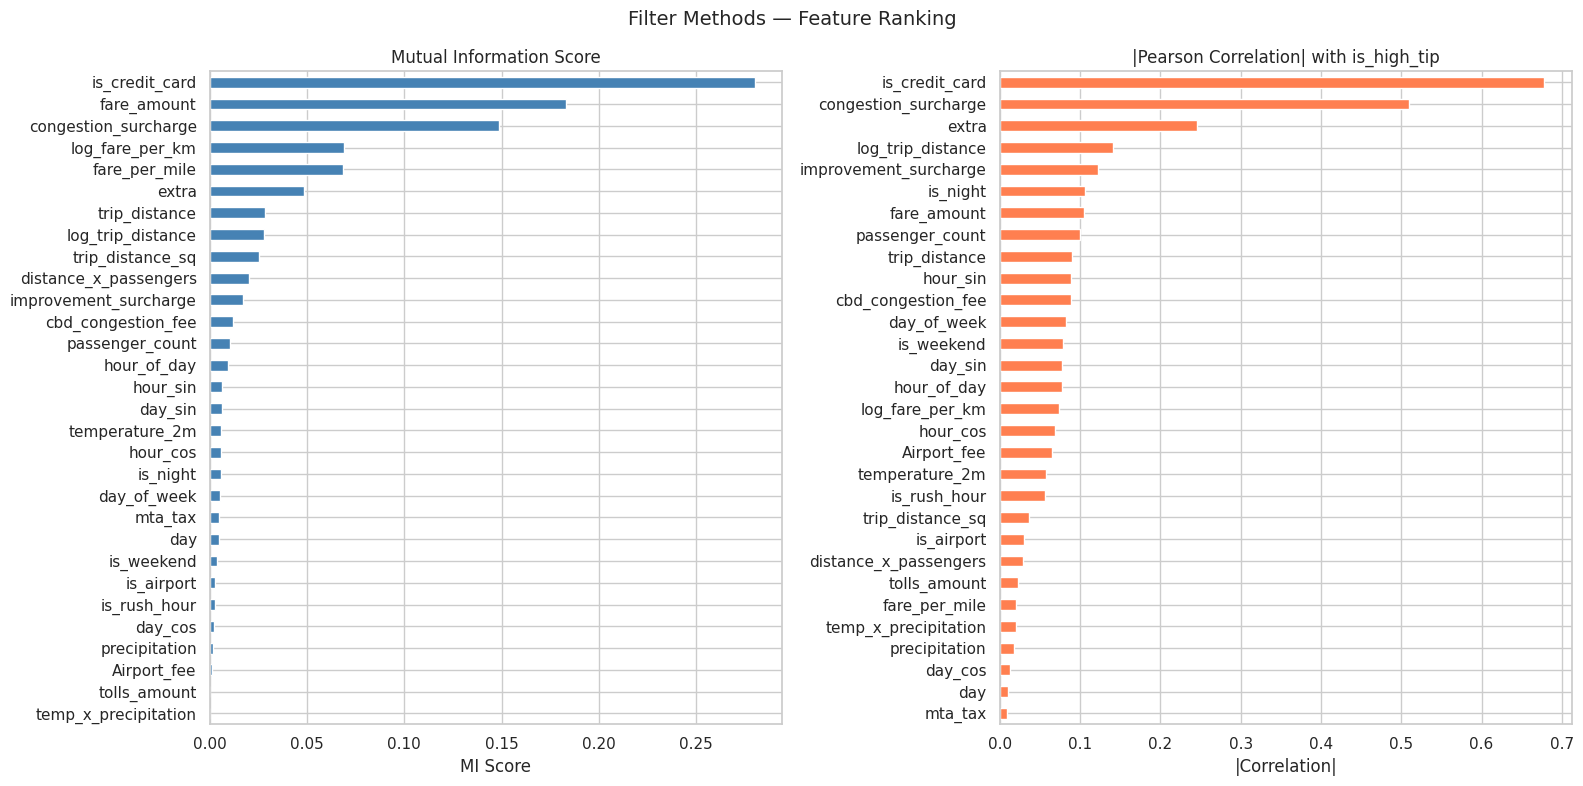

In [58]:
# ── Filter Methods (Variance Threshold + Pearson Correlation + Mutual Information) ──
vt, corr_target, mi_series, removed_low_var = FeatureSelector.run_filter_methods(
    X_all, y, FEATURE_COLS, sample, TARGET
)
FeatureSelector.plot_filter_methods(mi_series, corr_target)

#### 7.4.3. Embedded Method — Random Forest Feature Importance


Features at or above mean importance (3): ['is_credit_card', 'congestion_surcharge', 'extra']


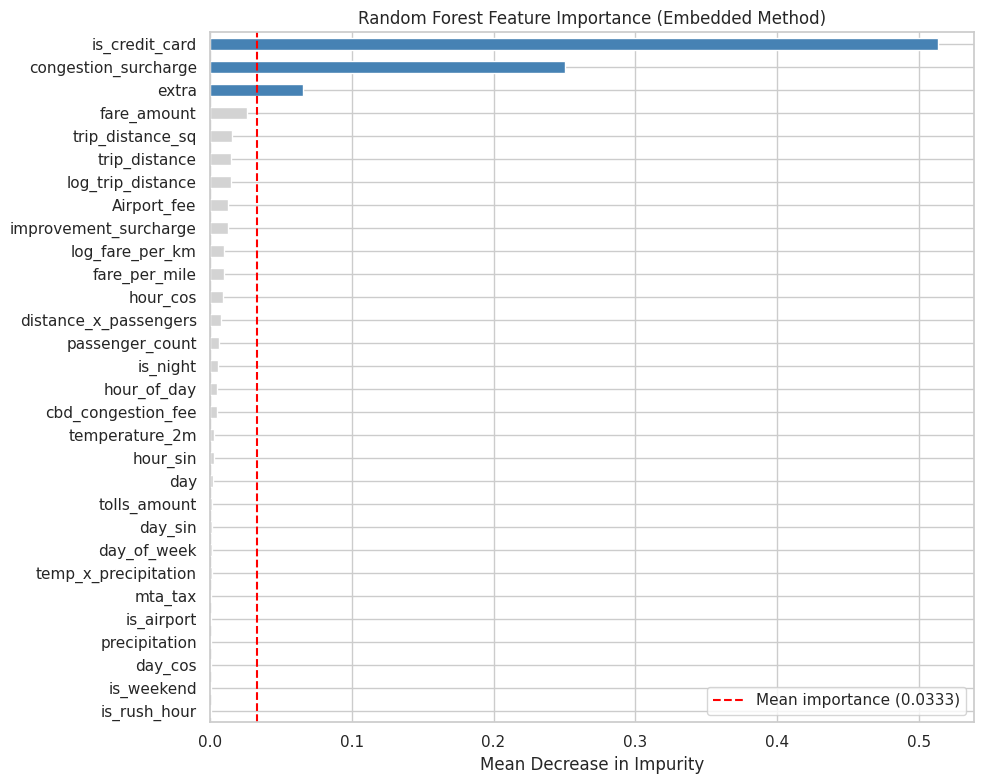

In [59]:
# ── Embedded Method — Random Forest Feature Importance ───────────────────────
rf_importance, rf_selected_features = FeatureSelector.run_embedded_method(X_all, y, FEATURE_COLS)
FeatureSelector.plot_embedded_method(rf_importance)

#### 7.4.4. Wrapper Method  (Recursive Feature Elimination (RFE))

In [60]:
# ── Wrapper Method — Recursive Feature Elimination (RFE) ────────────────────
rfe, rfe_ranking, rfe_selected = FeatureSelector.run_rfe(X_all, y, FEATURE_COLS)

RFE Feature Ranking  (1 = selected, higher = eliminated earlier):
trip_distance             1
extra                     1
improvement_surcharge     1
tolls_amount              1
congestion_surcharge      1
log_trip_distance         1
hour_of_day               1
log_fare_per_km           1
trip_distance_sq          1
hour_cos                  1
fare_per_mile             1
is_credit_card            1
day_of_week               2
cbd_congestion_fee        2
distance_x_passengers     3
mta_tax                   3
Airport_fee               4
passenger_count           4
is_night                  5
is_rush_hour              5
hour_sin                  6
temperature_2m            6
is_weekend                7
day_sin                   7
fare_amount               8
day                       8
is_airport                9
day_cos                   9
precipitation            10
temp_x_precipitation     10

RFE selected 12 features: ['trip_distance', 'extra', 'improvement_surcharge', 'tolls_amount',

#### 7.4.5. Feature Selection Summary

We combine scores from all three methods into a **composite ranking** and pick the
top 12 features that pass the variance threshold.  
This final set (`FINAL_FEATURES`) will be used by the supervised models in Section 3.

In [61]:
# ── Feature Selection Summary ────────────────────────────────────────────────
summary_df, FINAL_FEATURES = FeatureSelector.build_summary(
    mi_series, corr_target, rf_importance, rfe, FEATURE_COLS, vt
)

Feature Selection Summary (sorted by composite score):
                       MI_score  Correlation  RF_importance  RFE_rank  Variance_OK  composite_score
is_credit_card           0.2803       0.6784         0.5133         1         True           1.0000
congestion_surcharge     0.1486       0.5095         0.2502         1         True           0.5884
fare_amount              0.1832       0.1050         0.0262         8         True           0.2826
extra                    0.0484       0.2450         0.0656         1         True           0.2176
log_fare_per_km          0.0689       0.0732         0.0102         1         True           0.1204
log_trip_distance        0.0278       0.1404         0.0148         1         True           0.1080
fare_per_mile            0.0682       0.0207         0.0097         1         True           0.0932
improvement_surcharge    0.0167       0.1218         0.0125         1         True           0.0841
trip_distance            0.0284       0.0893 

### 7.5. Performance Comparison (All Features vs. Selected Features)

We train a **Logistic Regression** classifier on three feature sets and compare
AUC-ROC and Accuracy on a held-out 20 % validation split.

| Feature set | Description |
|-------------|-------------|
| All features (30) | Every engineered feature |
| RF selected | Features with above-mean Random Forest importance |
| Composite selected (top 12) | Top 12 by combined filter + embedded score |

> Logistic Regression is used here as a fast, interpretable baseline.  
> The full Random Forest and XGBoost models in Section 3 will train on `FINAL_FEATURES`.

                Feature Set  n_features  AUC-ROC  Accuracy
          All features (30)          30   0.8648    0.8373
                RF-selected           3   0.8445    0.8251
Composite-selected (top 12)          12   0.8627    0.8384


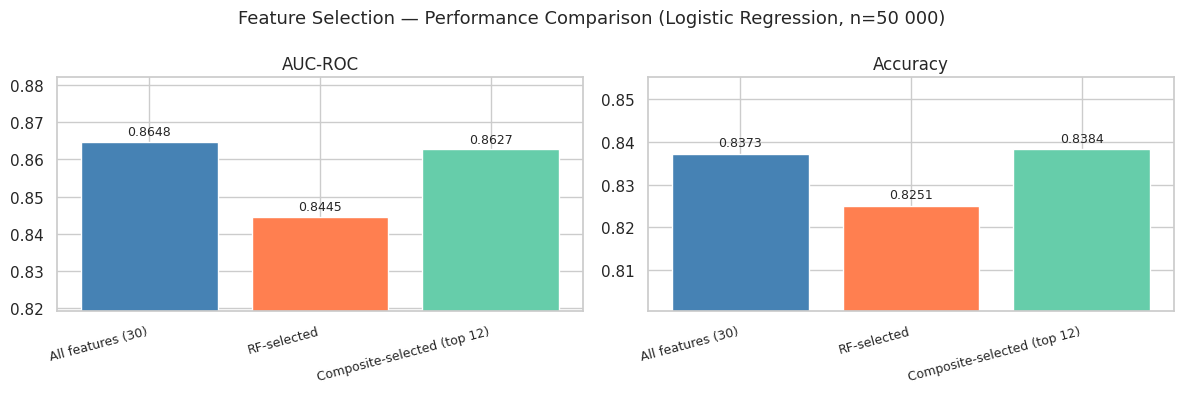

25813

In [62]:
# ── Performance Comparison (All Features vs. Selected Features) ─────────────
results_df = FeatureSelector.evaluate_feature_sets(
    X_all, y, FEATURE_COLS, rf_selected_features, FINAL_FEATURES
)
FeatureSelector.plot_performance_comparison(results_df)

# Free memory
del feat_df, sample, X_all, y, vt, rfe
gc.collect()

<br>

## <a name="p2-supervised">8.Advanced Supervised Learning</a>
___
This section involves training 2 advanced classifcation models: **Random Forest** and **XGBoost**.

The tasks involve the following tasks:
1. Check label distribution
2. Define the feaures X and the target variable y
3. Split dataset into training, validation and test sets
4. Tune the hyperparameters
5. Train the tuned models
6. Evaluate and compare the models' performance on test set

**RQ1 — Supervised Learning:**
> *"Can we classify a high-tipper passenger based on trip-selected features (distance, time of day, day of week, rate code, passenger count) and weather conditions (temperature, precipitation)?"*

- **Model Type:** Classification
- **Models:** Random Forest and XGBoost
- **Target variable:** `is_high_tip`

### 8.1. Check label distribution
The dataset contains **significant class imbalance** for both `payment method` and the target variable `is_high_tip`.
- Tips are primarly recorded for `Credit card` transactions.
- When a customer pays with `Cash`, tips are not recorded in the system, which sets `is_high_tip` to **False** systematically. This violates data integrity.
- The same systematic problem applies to other payment methods.

In [63]:
# Show the class imbalance
(taxi_df.groupby('payment_type', observed=False)['is_high_tip'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

payment_type  is_high_tip
Cash          False          100.0%
              True             0.0%
Credit card   True            74.5%
              False           25.5%
Dispute       False           93.8%
              True             6.2%
Flex fare     False           80.4%
              True            19.6%
No charge     False           98.0%
              True             2.0%
Unknown       False          100.0%
              True             0.0%
Name: proportion, dtype: object

The following plot (in logarithmic scale) shows that the majority of customers pay with `Credit card`, illustrating a significant class imbalance in `Payment Type`.

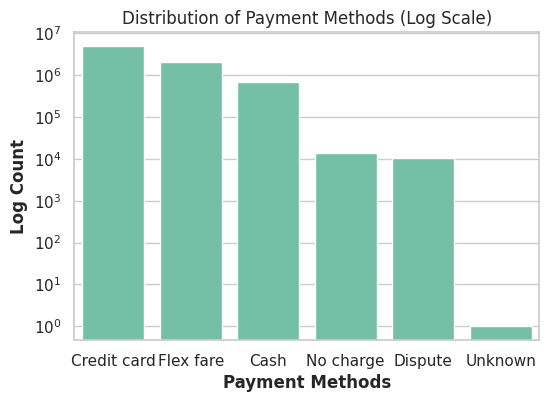

In [64]:
# Plot with a Log Scale to see the Payment Methods Distribution
pay_counts = taxi_df['payment_type'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=pay_counts.index, y=pay_counts.values, color='MediumAquamarine', order=pay_counts.index)
ax.set_yscale("log")

# Set titel and labels
plt.title('Distribution of Payment Methods (Log Scale)')
plt.ylabel('Log Count', fontweight='bold')
plt.xlabel('Payment Methods', fontweight='bold')
plt.show();

For data integrity, we need to keep records with `Credit card` transactions only.

`Low Tip` (False) is a **label noise** since people who tipped in cash or with other payment methods were recorded as $0.

In [65]:
# Filter out records with credit card transactions only
credit_card_df = taxi_df[taxi_df['payment_type']=='Credit card']

# Show label distribution
tip_distribution = credit_card_df['is_high_tip'].value_counts(normalize=True).to_frame()
tip_distribution['percentage'] = (tip_distribution['proportion'] * 100).round(2).astype(str) + '%'
tip_distribution.index = ['High Tipper (>=20%)', 'Low/Mid Tipper (<20%)']
display(tip_distribution)

,proportion,percentage
High Tipper (>=20%),0.744679,74.47%
Low/Mid Tipper (<20%),0.255321,25.53%


However, the filtered dataset `credit_card_df` still contains significant class imbalance among the tippers (74/25).

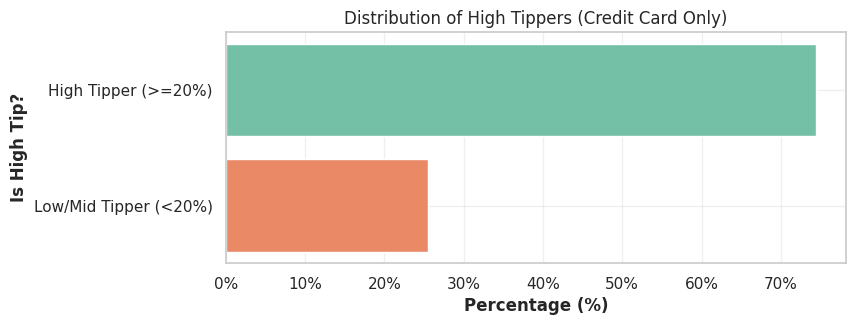

15985

In [66]:
# Plot the tipper label imbalance
fig, ax = plt.subplots(figsize=(8, 3))
sns.barplot(
    x=tip_distribution['proportion'],
    y=tip_distribution.index.astype(str),
    hue=tip_distribution.index.astype(str),
    palette=['MediumAquamarine', 'Coral'],
    legend=False,
    ax=ax
)

# Set title and labels
plt.title('Distribution of High Tippers (Credit Card Only)')
plt.xlabel('Percentage (%)', fontweight='bold')
plt.ylabel('Is High Tip?', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(alpha=0.3)
plt.show();

# Free up memory
del pay_counts, tip_distribution
gc.collect()

Before modelling the dataset, we need to remove the records with negative amount(s) in `credit_card_df` (which contains 1 row).

In [67]:
# Find records with negative fares
display(credit_card_df.loc[credit_card_df['is_negative']])

# Remove records with negative fares
credit_card_df = credit_card_df.loc[~credit_card_df['is_negative']]

,passenger_count,trip_distance,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,...,day_cos,is_rush_hour,is_weekend,is_night,is_airport,fare_per_mile,is_credit_card,trip_distance_sq,distance_x_passengers,temp_x_precipitation
2236012,1,3.47,Credit card,-19.1,-2.5,-0.5,5.27,0.0,-1.0,-21.08,...,1.0,1,0,0,0,0.0,1,12.0409,3.47,0.0


To address the imbalanced dataset, we must use the following tools:
- **Data Preparation**: Stratified K-Fold CV
- **Performance Metrics**: F1-score, ROC-AUC metrics, Confusion Matrix, Classification Report

### 8.2. Create samples

A representative random sample of **1 millions record**s are extracted from the dataset to optimize computational efficiency. **Stratification** is used to preserve the original class ratio.

Following the analysis in Section 7, we will use the `FINAL_FEATURES` list. Because the data is limited to credit card transactions, the `is_credit_card` feature at index 0 is redundant and will be removed.

In [68]:
# Sample 1 million records from the initial dataset
sample_df, _ = train_test_split(
    credit_card_df,
    train_size=1_000_000,                       # extract 1M rows randomly
    stratify=credit_card_df['is_high_tip'],     # preserve original class ratio
    random_state=42                             # for reproducibility
)

# Define variable X, y
X = sample_df[FINAL_FEATURES[1:]]       # Use FINAL_FEATURES
y = sample_df['is_high_tip']

# Inspect the number of rows and columns to train
print(f"X shape: {X.shape}")

X shape: (1000000, 11)


### 8.3. Split dataset

The dataset is splitted into 70%/15%/15%.

In [69]:
# 1. Get the 15% Testing set (by setting test_size=0.15)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=1)

# 2. Get 15% Validation set from the remaining 85% portion
# Training + Validation = temp = Remaining 85%
valid_ratio = 0.15 / 0.85
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=valid_ratio, random_state=1)

# Check
print(f"Train set: {len(X_train)/len(X):.1%}")
print(f"Valid set: {len(X_valid)/len(X):.1%}")
print(f"Test set:  {len(X_test)/len(X):.1%}")

Train set: 70.0%
Valid set: 15.0%
Test set:  15.0%


### 8.4. Tune Hyperparameters

We used **RandomSearchCV** instead of GridSearchCV for tuning the hyperparameters because of its effective and faster performance. Instead of searching all the combinations of parameters in the search space, RandomSearchCV uses mathematical computations to find the optimal configurations for the next iteration. We tuned the hyperparameters for both Random Forest and XGBoost on the **validation set**.
- The performance metric for tuning is **F1-Score**.
- To preserve original class ratio, we used Stratification.

> **WARNING**: Running the code below will take around **10 minutes.**

In [70]:
# ── STEP 1: Define the search space for each model ────────────────────────────

# Random Forest Search Space
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],              # to avoid overfitting
    'min_samples_leaf': [50, 100],
    'max_samples': [0.1, 0.2]           # Trains each tree on only 10-20% of the 1M rows
}

# XGBoost Search Space
xgb_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],             # to avoid overfitting
    'learning_rate': [0.01, 0.1]
}


# ── STEP 2: Define the models ─────────────────────────────────────────────────
models = {
    'RandomForest': (RandomForestClassifier(
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ), rf_grid),

    'XGBoost': (XGBClassifier(
        tree_method='hist',
        scale_pos_weight=1,           # let StratifiedKFold to handle class imbalance
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',        # criterion for binary classification
        random_state=42
    ), xgb_grid)
}


# ── STEP 3: Tune the hyperparameters with RandomizedSearchCV ──────────────────
hparams_results = Evaluator.run_hparams_search(models, X_train, y_train, X_valid, y_valid)
Evaluator.display_hparams_search(hparams_results)

Elapsed time for RandomForest: 284.01s
Elapsed time for XGBoost: 113.60s

--- Model Comparison ---


,model,cv_f1_mean,valid_f1_score,train_time
0,RandomForest,0.8637,0.8636,284.01
1,XGBoost,0.8637,0.8635,113.60


**Interpretation**:
- F1-score is a reliable performance metric for imbalanced dataset. This harmonic mean balances between Precision and Recall.
- Both models have good and identical F1-scores, showing that they classify labels mostly correctly (86%) on both training and validation sets.
- Identical F1-scores across 3-fold CV (`cv_f1_mean = 0.8637`) and the unseen validation sets (`valid_f1_score = 0.8636`) indicate that both models are stable and show no significant overfitting.
- XGBoost has a significant faster speed for training than Random Forest.

**Result**: Here are the best hyperparameters found by RandomSearchCV.

In [71]:
# Extract the best hyperparameters
rf_params = hparams_results[0]['best_params']
xgb_params = hparams_results[1]['best_params']

# Display the hyperparameters
print(f"Best Hyperarameters (Random Forest): {rf_params}")
print(f"Best Hyperarameters (XGBoost): {xgb_params}")

Best Hyperarameters (Random Forest): {'n_estimators': 100, 'min_samples_leaf': 50, 'max_samples': 0.2, 'max_depth': 15}
Best Hyperarameters (XGBoost): {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}


### 8.5. Training Phase
Both Random Forest and XGBoost models are retrained on the training set using their respective best-performing hyperparameters.

In [72]:
# Initialize the tuned Random Forest model
rf = RandomForestClassifier(
    **rf_params,
    class_weight=None,
    random_state=42,
    n_jobs=-1)

# Initialize the tuned XGBoost model
xgb = XGBClassifier(
    **xgb_params,
    early_stopping_rounds=10,
    tree_method='hist',
    scale_pos_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42)

# Train both models
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### 8.6. Model Evaluation and Comparison

A final evalution is conducted on the tuned models with the held-out test set.
The performance metrics are:
1. Confusion Matrix
2. Classification Report
3. ROC-AUC

In [73]:
# Compute the predictions on the test set
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

#### 8.6.1. Confusion Matrix

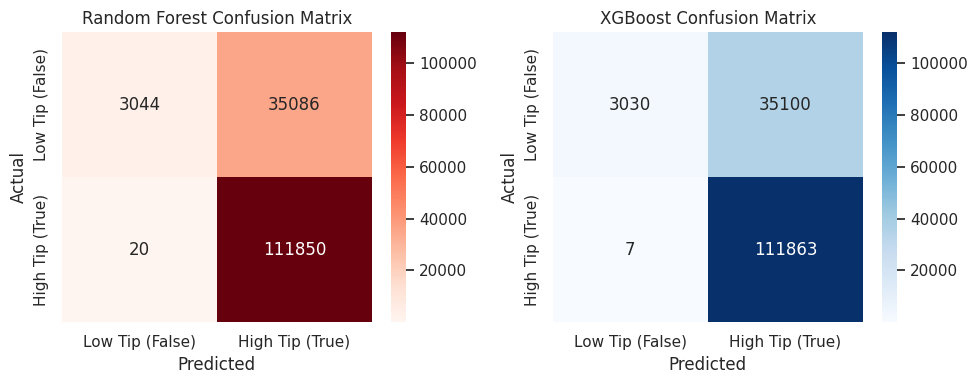

In [74]:
Evaluator.display_confusion_matrix(y_test, y_pred_rf, y_pred_xgb)

**Interpretation:**
- Both models show nearly identical confusion matrices, indicating **performance convergence**.
- Since both Random Forest (Bagging) and XGBoost (Boosting) are built upon Decision Tree ensembles (same foundation basis), it is expected that they converge on similar performance scores when provided with the same feature set.
- Both models correctly classify most of `High Tip` (True) as `High Tip` (True) labels.
- Both confusion matrices reveal a **consistent error pattern**: `Low Tip` (False) data are frequently misclassified as `High Tip` (True).
- This indicates that both models fail to distinguish `Low Tip` records from `High Tip` records. The dataset is clearly biased towards high tippers.
- **XGBoost** is slightly more performant, recording 13 fewer False Negatives (7 vs 20) than Random Forest.
- **Model Selection**: While the difference between the two models is minimal (varying by only a few counts), **XGBoost** is the selected model. It captures the `High Tip` (True) class more accurately.

#### 8.6.2. Classification Report

In [75]:
# Display classification report for both models
Evaluator.display_classification_report(y_test, y_pred_rf, y_pred_xgb)

# Build a merged classification report
merged_reports = Evaluator.build_merged_classification_report(y_test, y_pred_rf, y_pred_xgb)
pd.DataFrame(merged_reports)


--- Classification Report: RANDOM FOREST ---
              precision    recall  f1-score   support

       False       0.99      0.08      0.15     38130
        True       0.76      1.00      0.86    111870

    accuracy                           0.77    150000
   macro avg       0.88      0.54      0.51    150000
weighted avg       0.82      0.77      0.68    150000


--- Classification Report: XGBOOST ---
              precision    recall  f1-score   support

       False       1.00      0.08      0.15     38130
        True       0.76      1.00      0.86    111870

    accuracy                           0.77    150000
   macro avg       0.88      0.54      0.51    150000
weighted avg       0.82      0.77      0.68    150000



,Model,Accuracy,Macro F1,Weighted F1,Recall (False),Precision (True)
0,RandomForest,0.765960,0.506071,0.682203,0.079832,0.761216
1,XGBoost,0.765953,0.505785,0.682062,0.079465,0.761164


**Intepretation:**
- **Performance Convergence**: Both models show identical classification reports. Both models are based on Decision Tree and reached the predictive power limit on the same set of feature.
- **High Recall (1.00)**: Both models successfully identify almost all `High Tip` (True) records.
- **Moderate Precision (0.76)**: Both models have a moderate precision. The `Low Tip` (False) are frequently misclassified as `High Tip` (True).
- **Low Recall (Low Tip)**: Both models fail to accurately classify `Low Tip` (False). Both models ignore False labels with a poor recall of 0.08.
- **Accuracy**: An accuracy of 0.77 is misleading due to the 75/25 class imbalance.
- **Low Macro F1**: This low metric indicates that both models fail to classify the minority class `Low Tip` (False). Both models fail to distinguish between the two classes effectively.
- **Model Selection**: The classification reports show a tie. We need further performance metrics to compare models.

#### 8.6.3. ROC-AUC

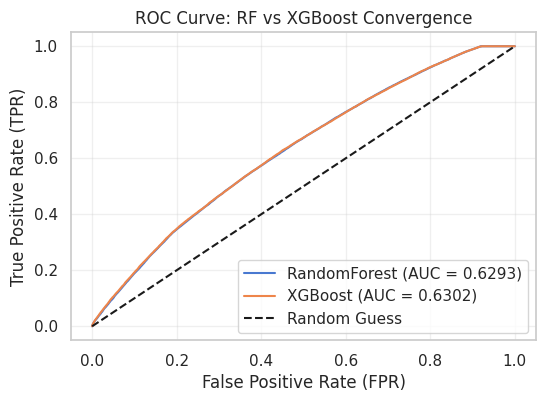

In [76]:
# Define the models
models = {'RandomForest': rf,
          'XGBoost': xgb}

# Compute and display ROC-AUC
auc_scores = Evaluator.display_roc_auc(models, X_test, y_test)

**Intepretation:**
- **Performance Convergence**: Both models show nearly identical AUC scores, indicating that both models reached similar predictive power limit on this feature set.
- **Random Forest's AUC Score**: around 0.6293.
- **XGBoost's AUC Score**: around 0.6302 (a sligthly higher score).
- Both AUC scores are moderate, showing that they struggle to distinguish between two classes (`High Tip` vs `Low Tip`).
- Both ROC curves lean toward the y-axis (True Positive Rate), confirming that both models are effective at identifying nearly all `High Tip` (True) class.
- Both ROC-AUC curves overlap, indicating that both models are equally limited by the features provided.
- **Model Selection**: Since XGBoost performs slightler better than Random Forest, **XGBoost** is selected as the best-performing model.

#### 8.6.4. Feature Importance

In this section, we inspect which features influence the most in each model during training phase: Random Forest and XGBoost. This enables to **investigate** whether they behave differently on the same set of features.

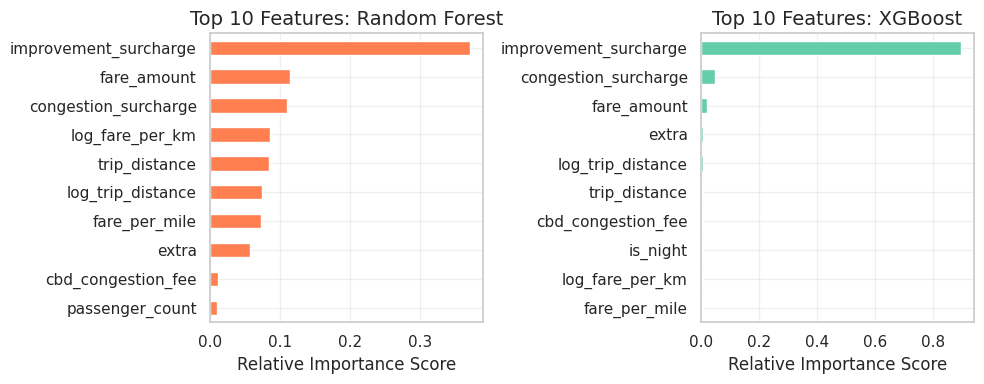

In [77]:
Evaluator.display_feature_importance(hparams_results=hparams_results,
                                     train_columns=X_train.columns)

**Interpretation**:
- Even if Random Forest and XGBoost provide the nearly identical performance scores, the plots above confirm that the models prioritize features differently.
- For both models, the primary predictor is `improvement_surcharge`, confirming the performance convergence.
- **Random Forest** gives more distributed importance across secondary features: `fare_amount` and `congestion_surcharge`.
- **XGBoost** puts little/none additional value in other features, making a sparse distribution. It concentrates all the weight on one single feature: `improvement_surcharge`.
- Because both models prioritize the same top three features (`improvement_surcharge`, `fare_amount` and `congestion_surcharge`), it explains why they achieve nearly identical performance metrics. This convergence suggests that both models successfully identify the same primary drivers of tipping behavior, regardless of their different algorithmic approaches (Bagging vs. Boosting).

<br>

### 8.7. Model Selection

In [78]:
Evaluator.build_comparison_table(hparams_results, merged_reports, auc_scores)

,Model,Train Time (sec),CV F1,Valid F1,Macro F1,Recall (False),Precision (True),AUC
0,RandomForest,284.01,0.8637,0.8636,0.5061,0.0798,0.7612,0.6293
1,XGBoost,113.60,0.8637,0.8635,0.5058,0.0795,0.7612,0.6302


**Internal Metrics**

Both models achieved identical F1-scores (around 0.86) across 3-fold CV (`CV F1`) and the unseen validation sets (`Valid F1`), indicating stable performance and a lack of overfitting. The consistency between training and validation suggests the models have successfully generalized data patterns.

<br>

**External Metrics on the held-out Test set:**

Both Random Forest and XGBoost have nearly identical performance metrics on the unseen held-out test set across the confusion matrix, confusion reports and ROC-AUC scores.

<br>

**Model Selection**

**XGBoost** is selected as the **best model** for this specific 1,000,000-record binary classification problem for the following reasons:

- **Accuracy**: It identifies the `High Tip` (True) class more accurately in the confusion matrix.
- **Predictive Power**: It achieves a slightly higher AUC score (0.6302).
- **Efficiency**: It performs **significantly faster** than Random Forest, with a training time of ~150s compared to ~250s.
- **Optimized Architecture**: As a sequential ensemble, XGBoost effectively corrects the residual errors from previous trees, ensuring an optimized performance.

> **NOTE**: The performance on the test set will be discussed more in details in [Section 10: Evaluation](#p3-evaluation).

In [79]:
# Free up memory
del (credit_card_df, sample_df,
     X, y, X_temp, y_temp, X_valid, y_valid,
     rf_grid, xgb_grid, fig,
     hparams_results, rf_params, xgb_params, merged_reports, auc_scores)

%reset -f out
gc.collect()

Flushing output cache (8 entries)


0

<br>

## <a name="p2-unsupervised">9.Unsupervised Learning</a>
___
Our unsupervised learning model will be a K-Means clustering model based on the research question:

**RQ2 — Unsupervised Learning:**
> *"Can we identify the distinct natural clusters of NYC taxi trips based on their temporal, financial to study customer behavior?"*

<br>

- **Models**: PCA, K-Means
- **Features used**: `log_trip_distance`, `log_fare_per_km`, `tip_ratio`, `hour_of_day`, `day_of_week`, `passenger_count`, `temperature_2m` and `precipitation`.

<br>

`log_trip_distance`, `log_fare_per_km` and `tip_ratio` are transformations of the features `trip_distance`, `fare_amount` and `tip_amount`. Because of their range and variance, and their interconnectedness, these features would have too much weight in a distance based model, especially for K-Means. By using the properties of **logarithms** and by **decoupling** both the fare from the distance and the tip from the fare, our features are more equal in influence.

<br>

The tasks involve the following:

1. Select our features
2. Create a subsample of 10k for the purpose of finding the best value of the hyperparameter K
3. Scale the features using sklearn's RobustScaler
4. Apply PCA to get principal components.

We will then look at the explained variance ratio of the components, and keep the components that explain at least 90% of the variance, starting with the first which explain the most variance, and going from there.

In [80]:
# Create a subsample of 10K rows
mask = taxi_df['fare_amount'] >= 0
cluster_df = taxi_df.loc[mask, ['log_trip_distance', 'log_fare_per_km', 'tip_ratio', 'hour_of_day', 'day_of_week', 'passenger_count', 'temperature_2m', 'precipitation']]
training_sample = cluster_df.sample(n=100000, random_state=1)

# Normalize X
scaler = RobustScaler()
sample_X = scaler.fit_transform(training_sample)

# Compute PCA
principal_components = kmeans_utils.select_PCA(sample_X)

[0.3212831  0.16968578 0.13091551 0.10989789 0.10051379 0.07004664
 0.05764836 0.04000892]
Total variance of the first 6 principal components 90.2%


**Observation**: We can see from the result that the first 6 components explain around 90% of the variance. We will keep them for our model.

### 9.1. Elbow method

The next step is to find the best value of K. For this purpose, we will use the elbow method, calculating the inertia of the MiniBatchKMeans model at each value of K in our chosen range of candidate K, from 2 to 20.

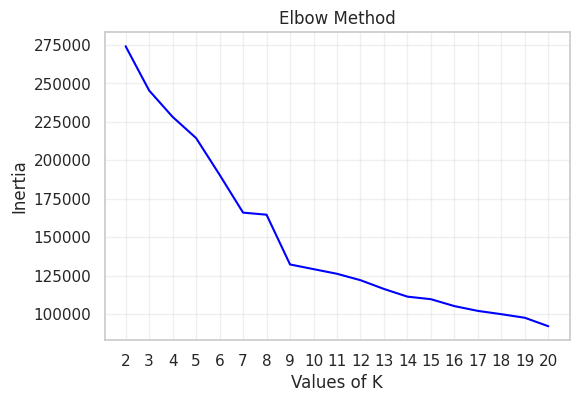

In [81]:
kmeans_utils.elbow_method(principal_components)

**Observation:** From the graph, we can see that the "elbow" starts at k = 7. After that, the trend is clearly towards a lower slope of inertia.

### 9.2. PCA

Now that we have our value for our hyperparameter K, we will use PCA on our full dataset and train our final MiniBatchKMeans model.

In [82]:
# Apply PCA
X = scaler.fit_transform(cluster_df)
principal_components = kmeans_utils.select_PCA(X)

[0.31816742 0.16898227 0.13405381 0.11147921 0.1005594  0.0694467
 0.05768986 0.03962137]
Total variance of the first 6 principal components 90.3%


Again, on the full set, the first 6 principal components account for 90% of the variance, and the variance ratio is very similar to the subsample's ratio. Now, we train our model.

### 9.3. Train K-Means

In [83]:
kmeans_dict = kmeans_utils.train_and_summarize(cluster_df, principal_components, k=7)
kmeans_dict['summary']

,mean log_trip_distance,mean log_fare_per_km,mean tip_ratio,mean hour_of_day,mean day_of_week,mean passenger_count,mean temperature_2m,mean precipitation,cluster size
cluster,,,,,,,,,
0,2.370563,1.646047,0.098875,13.328443,3.146493,1.146939,25.563156,0.081353,1278477
1,0.565694,2.863692,0.069444,14.725197,2.947186,1.120927,28.225578,0.119059,567919
2,0.730027,2.316492,0.262136,15.580690,2.338069,1.136279,28.977341,0.092505,1684697
3,1.305365,2.031020,0.108660,17.501325,3.011942,1.100935,28.808540,0.076370,1855081
4,1.128513,2.213753,0.173154,15.494644,1.932631,1.227052,24.102079,6.479051,68993
5,1.087631,2.084781,0.136836,8.641821,3.399475,1.092050,20.984102,0.086115,1560572
6,1.199494,2.135213,0.180176,14.904824,3.264293,3.686697,26.848799,0.086241,331605


Our summary is based on the mean for each features of our dataset according to their cluster, as well as the size of the cluster on the last column. We can make the following observations:
- **Cluster 0** has a significantly higher `trip distance` than any other clusters. We could identify it as the **long trip distance cluster**.

- **Clusters 1 and 2** have significantly **lower `trip distance`** than the other clusters, but do not have any features strongly separating them from each other. This suggests that while the elbow method showed 7 as our best k, it might have forced a separation on what would have been a more natural, short distance cluster. This is supported by cluster 1 having hundreds of thousands of entries, instead of the millions found in clusters 0, 2, 3 and 5, suggesting that it might have been split off from 2.

- **Cluster 3** has `trip_distance` lower than cluster 0 but higher than clusters 1 and 2. While it is similar to clusters 4, 5 and 6, each of those clusters have clear differences on other features. This suggests that cluster 3 acts as a middle cluster between short and long trips, with no other special caracteristics. We could identify it as the **medium-length trip distance cluster**.

- **Cluster 4** has an extremely small number of observations, and extreme high values of `precipitation` in comparison to other clusters. The small size suggests it is noise, but the very clear separation on `precipitation` tends toward a real, if isolated and small, delineation. It could be identified as the **rainy days cluster**.

- **Cluster 5** has a lower `hour of day` than the other clusters, being in the morning while the other's means all go toward mid-afternoon. Thus, it could be identified as the **morning cluster**.

- **Cluster 6** has a significantly higher mean `passenger count` than other clusters. It could be identified as the **group trip cluster**. It should be noted that while it is not quite as small as cluster 4, it is still a significantly smaller cluster than average, ressembling cluster 2.

<br>

The table below summarizes our clustering model.

| Cluster | Classification |
| :-- | :-- |
| 0 | Long Trip Distance |
| 1, 2 | Short Trip Distance |
| 3 | Medium-Length Trip Distance |
| 4 | Weather-Impacted |
| 5 | Peak Morning |
| 6 | High-Occupancy |   

### 9.4. Visualization with PCA

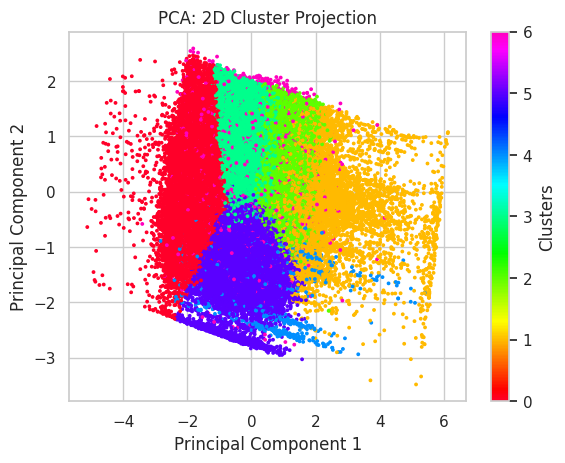

In [84]:
kmeans_utils.visualize_2D_clusters(principal_components, kmeans_dict['labels'])

This graph is based on the two first principal components, which explain around 48% of the variance. This limits the clarity of our results in exchange for creating a graph that is readable by humans. Our observations here are:

- The large, more strongly delineated than others **red** and **dark blue** clusters correspond to our ***long distance trips*** and ***morning trips***. This suggests that these features create strong separation in clustering and are good for determining patterns in taxi behavior.

- The **yellow** and **green clusters** are the ***short trip clusters***. The **teal cluster** is the ***medium-lenght trip*** cluster. We can see that they blend with each other, suggesting that the difference between short and medium-lenght trips is not as significant as with long trips, and that these are likely an artificial separation caused by our choice of k = 7.

- **The purple cluster** is ***group trips***, while the **light blue cluster** is ***rainy days***. We can see that those do not have a strong shape, and instead are scattered inside other clusters. This suggests that, while there is an underlying pattern, it is weak and probably better explained by other principal components of the PCA.

### 9.5. Silhouette and Davies-Bouldin Scores

In [85]:
print('Silhouette score: ' + str(kmeans_dict['silhouette_score']))
print('dbScore: ' + str(kmeans_dict['Davies_Bouldin_score']))

Silhouette score: 0.17817307
dbScore: 1.3461854807517564


- **Silhouette score** is quite low, at around 0.18. Silhouette goes from 1 to -1, with the higher score being better, as it indicates compact clusters far away from each other. However, because we are working on real world behavioral data, such well separated clusters are often impossible to obtain. We can say that the silhouette score confirms what we observed in our graph: the clusters are closely packed, to the point of overlapping, and that some act more like noise scattered through other clusters. Thus, we can see that despite our first 2 principal components accounting for only 48% of the variance of our dataset, it still creates a representative graph for our results.

<br>

- **Davies-Bouldin score** is higher than is preferable. Davies-Bouldin goes from infinity to 0, with 0 being ideal, and values under 1 being prefferable. **Our result is 1.35**. This tends to support the results of the silhouette score and the graph, showing clusters that are not well-separated: Their borders are very close and overlap often. This can be seen as a limit of clustering on real-world data.

<br>

___
___
# <a name="Phase-3">Section C: Project Phase 3 — Discussion</a>

## <a name="p3-evaluation">10.Evaluation</a>

In this section, we evaluate the **unbiased performance of the models**. As seen in [Section 8: Supervised Learning](#p2-supervised), the initial performance metrics (Confusion Matrices, Classification Reports, F1-Scores, and ROC-AUC) provided near-identical conclusions for both Random Forest and XGBoost.

To determine the most robust model, the final evaluation is conducted exclusively on the **held-out test set** using three specialized metrics:

- **Precision-Recall Analysis**
- **Threshold Analysis**
- **Bootstrap Confidence Intervals**

This approach ensures that the reported results represent the **true ability** of each model to predict customer tipping behavior on **unseen data**.


### 10.1. Precision-Recall Curve

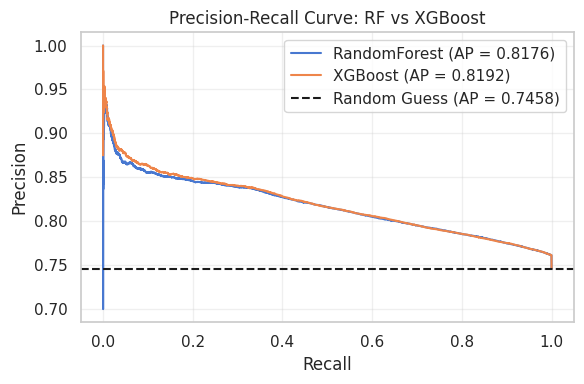

In [86]:
ap_scores = Evaluator.display_precision_recall_curve(models, X_test, y_test)

In [87]:
# Display the Average Precision in a DataFrame
pd.DataFrame(ap_scores)

,Model,Average Precision
0,RandomForest,0.8176
1,XGBoost,0.8192


**Interpretation**:

The existing ROC-AUC metric is misleading when class distributions are imbalanced. It stays relatively high even if the model struggles to identify the minority class (Low Tip). The Precision-Recall curve provides a more rigorous assessment by focusing only on the performance of the positive class (High Tip).
- **Average Precision (AP) Results**: XGBoost's AP was **0.8192**, whereas Random Forest's was **0.8176**.
- **Baseline**: The random guess baseline (dashed line) is **0.74**. This value represents the proportion of high-tip records in the dataset. Both models significantly outperform this baseline.
- **Conclusion**: The slightly higher AP for XGBoost confirms it is more effective at balancing precision and recall for this binary classification task on the test set. This validates the selection of XGBoost as the optimal model.

**Metric Definitions:**
- **Recall (X-axis):** The proportion of actual high-tip trips that were correctly identified by the model.
- **Precision (Y-axis):** The proportion of predicted high-tip trips that were actually high-tip trips.
- **AP Score:** Represents the area under the PR curve. A higher score indicates the model is maintaining high precision even as recall increases.


### 10.2. Threshold Analysis

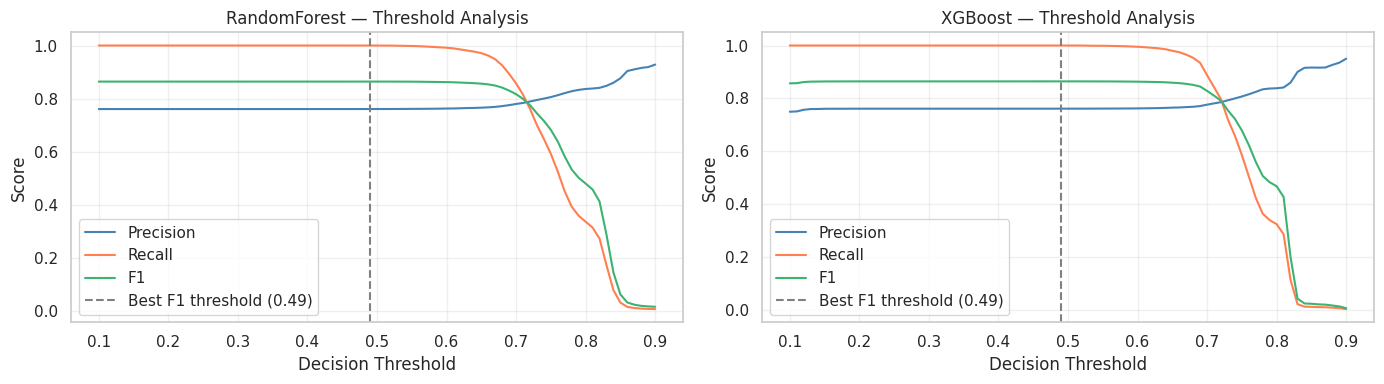

In [88]:
Evaluator.display_threshold_analysis(models, X_test, y_test)

**Interpretation:**

The **Threshold Analysis** is a statistical tool used to determine the optimal decision cutoff for categorizing `High Tip` vs. `Low Tip` trips. By default, classifiers predict a `High Tip` **when the probability is at least 0.5**, but this default cutoff is not always the most effective for classification.
By varying the threshold from 0.1 to 0.9, we can assess the trade-off between Precision, Recall, and the resulting F1-score.

- **Optimal Threshold:** At a threshold of **0.49**, both Random Forest and XGBoost reached their maximum F1-score on the test set. This near-default value suggests that the models are well-implemented for the current feature set. This result also validates our successful hyperparameter search.

- **Performance Plateau:** The F1-score for both models remains stable between thresholds of **0.1 and 0.6**. This indicates that the models maintain consistent predictive power.

- **Recall Drop (Threshold > 0.7):** Beyond a threshold of **0.7**, the Recall score drops significantly for both models. This indicates that the models struggle to make high-confidence predictions for the `High Tip` class. Therefore, the models perform best within the 0.4 and 0.6 range for this specific dataset.

- **Conclusion:** Both models are relatively effective at classifying `High Tip` and `Low Tip` records when threshold is set to **0.49**, and achieve near-identical performance. This validates the selection of **XGBoost** as the optimal model based on its faster training speed and computational efficiency.

### 10.3. Bootstrap Confidence Interval

In [89]:
Evaluator.compute_bootstrap_ci(y_test, y_pred_rf, y_pred_xgb, models, X_test)

,Model,F1 (95% CI),AUC (95% CI)
0,RandomForest,"0.8643 [0.8630, 0.8659]","0.6293 [0.6259, 0.6327]"
1,XGBoost,"0.8644 [0.8629, 0.8659]","0.6303 [0.6266, 0.6337]"


**Interpretation:**

The **Bootstrap Analysis** is a rigorous statistical tool used to compute the **95% Confidence Intervals (CI)** for the **F1-Score** and **AUC** over 500 iterations. This metric was used because a single F1-Score (0.86) can be influenced by the specific luck of the data split. The CI provides a more reliable assessment of the model's true performance.
- **Confidence Interval Overlap:** The results show that the confidence intervals for both models overlap almost perfectly. For the F1-Score, Random Forest $[0.8630, 0.8659]$ and XGBoost $[0.8629, 0.8659]$ are not significantly different. This indicates that both models have equivalent predictive power.

- **Narrow Intervals:** The intervals for both models are narrow, which indicates high model stability and confirms that the 1,000,000-record sample size is sufficient for a reliable estimate.

- **Conclusion:** This final metric validates that both models have near-identical classification performance on the test set. Thus, the selection of **XGBoost** is justified based on its higher computational efficiency and faster training time.

<br>

## <a name="p3-insights">11.Insights</a>
____

### 11.1. Feature Importance:  What Drives High Tipping?

We reuse the Random Forest trained in Section 2.4.3 to interpret which features most influenced the prediction of `is_high_tip`.  
The chart below shows each feature's importance score (mean decrease in impurity across all trees).

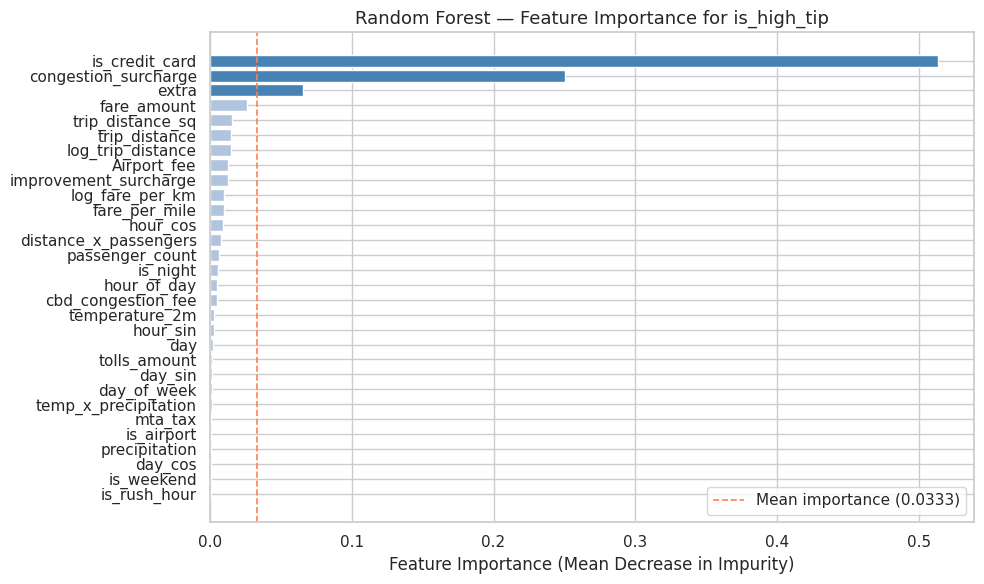

Top 5 features:
is_credit_card          0.513328
congestion_surcharge    0.250238
extra                   0.065613
fare_amount             0.026228
trip_distance_sq        0.015403
dtype: float64


In [90]:
# ── Feature Importance Bar Chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue' if v >= rf_importance.mean() else 'lightsteelblue'
          for v in rf_importance.values]

ax.barh(rf_importance.index[::-1], rf_importance.values[::-1], color=colors[::-1])
ax.axvline(rf_importance.mean(), color='coral', linestyle='--', linewidth=1.2,
           label=f'Mean importance ({rf_importance.mean():.4f})')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest — Feature Importance for is_high_tip', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(rf_importance.head())

**Interpretation:**

- **`is_credit_card`** is the dominant feature. Cash passengers almost never tip electronically — the payment terminal is what prompts tipping. This is a structural effect of the payment system, not passenger generosity.
- **`fare_per_mile`** and **`log_fare_per_km`** rank highly, confirming that trip cost efficiency matters: passengers on expensive-per-mile trips (e.g., short airport transfers) tend to tip more.
- **`tip_ratio`** is excluded from this analysis (data leakage,  it is derived directly from `tip_amount`).
- Time features (`hour_sin/cos`, `day_sin/cos`) and weather features have low importance, suggesting tipping behavior is driven more by trip economics and payment method than by when or in what conditions the trip occurs.

> **Connection to RQ1: Supervised Learning**
- The model can classify high tippers primarily from payment method and fare structure **not** from time or weather. This simplifies the feature set needed for Section 3.
- The training phase (*Section 3.6.4 - Feature Importance*) for both Random Forest and XGBoost confirms that certain features, specifically weather data (`temperature_2m` and `precipitation`), lack significant predictive power.
- The common top predictors for both models are `improvement_surcharge`, `fare_amount` and `congestion_surcharge`.
- **Conclusion**: Based on the results of this project, customer tipping behavior is not significantly influenced by weather conditions or time of day. Instead, the primary drivers of high-tip instances are transactional features, such as payment method and fare structure.

<br>

### 11.2. Insights on Supervised Learning
Here are the key observations from supervised learning.
- **Convergence Performance**: Both **Random Forest (Bagging)** and **XGBoost (Boosting)** achieved nearly identical performance metrics. Because both models are built on **Decision Trees** and prioritized the same top features (Section 3.6.4), the results are functionally the same. This suggests that the predictive power is limited by class imbalance and label noise in the NYC Taxi data, not the choice of algorithm.


- **Accuracy Paradox**: The high Validation F1-score (0.86) is misleading. Because the dataset is imbalanced (75/25), both models effectively classified the majority "True" labels but failed to generalize the minority "False" cases. While it suggests strong performance, the significantly lower Macro F1 reveals that both models struggled to perform on the held-out set. This illustrates a primary real-world challenge with supervised learning on the unseen imbalanced dataset.


- **Feature Importance**: The feature importance plots (see Section 3.6.4) show that both models prioritize the same three predictors: `improvement_surcharge`, `fare_amount` and `congestion_surcharge`. The consistency across different architectures (Bagging vs Boosting) identifies these as reliable predictors. However, the mediocre AUC scores (0.62) reveal that feature distributions for "low tip" and "high tip" might be heavily overlapping. The current feature set cannot fully capture the complexities of customer tipping behavior. We might need to collect other features (e.g., service quality).

> **Connection to RQ1: Supervised Learning**
- Both Random Forest and XGBoost struggly to classify and distinguish High Tippers and Low Tippers accurately. The performance on the test set reveals that the current models cannot fully explain the complexities of client tipping behaviour.

<br>

### 11.3. Insights on Unsupervised learning
Our experience with the K-means algorithm clearly demonstrates the importance of using multiple metrics to analyse the results of a machine learning model. Each metric used revealed a different aspect of our clustering, and lead to a fuller understanding:

- The **summary** where we projected the cluster made with the **PCA** back on the original features allowed us to clearly see which features most defined each clusters. It did, however, lead to an appearance that most of the clusters were more differenciated than in reality.

- The **graph** revealed quite a bit
  - about the real structure of our clustering,
  - how the clusters were close to the point of overlapping,
  - and how some were spread through other clusters.
  
  Still, we could see that the clusters that seemed most differentiated in the summary also had more defined borders. However, since the real clustering was done in a 6-dimensional space, which would be impossible for humans to understand visually, and the chosen components for the graph only accounted for around 42% of the variance of the dataset, it would have been an error to draw conclusions from it.

- The **Silhouette** and **Davies-Bouldin Score** confirmed the intuition from the graph, that the clusters were not very well-separated. They likely overlapped at times. This is likely a reality of clustering on real world behavioral data. The summary showed that our K-Means model still gave us clustering with real meaning. We would have missed this distinction if we had only used the scores as our metric of evaluation.

> **Connection to RQ2: Unsupervised Learning**
- The K-Means clustering algorithm identified 7 distinct customer clusters based on trip distance, passenger count (occupancy), weather and temporal factors.
- The cluster distributions yields the following insights:
  - **Primary demands**: The majority of taxi demand in June–July 2025 is clustered for Short and Mid-range trips (Clusters 3 and 2). This suggests the service is primarily used for routine,
  - **Peak Morning commutes (Cluster 5)** is the 3rd biggest and consistent cluster, corresponding to the commute patterns.
  - **Long trip distance (cluster 0)** is the 4th biggest cluster, likely corresponding to airport transfers or inter-borough travel.
  - **Cluster 4 (Weather-Impacted)** contains the fewest data points. This indicates that customers were significantly less likely to use taxis during rainy periods in this dataset.


### 11.4. Actionable Conclusions

The results of our supervised learning models indicate that transactional features such as `improvement_surcharge` and `congestion_surcharge` are most influencial in high tipping. As such, we could modify the surcharges to find which modification most encourages high tipping.

The results of our unsupervised learning model indicate that the clearest separators of taxi trips are the distance and the time of the day. Applying the modifications to surcharges along those separating factors would allow us to identify how different types of client react to the modifications.

## <a name="p3-ethics">12.Ethical Considerations</a>

### 12.1. Discussion of bias

In data analysis, some decisions taken to make the data more useable or to extract more meaning can **introduce bias** to the data. These situations are often a balancing act between the introduced bias and the information gain obtained. It is important to **recognize and catalogue those biases** to take them into account during analysis of results.

**During data wrangling:**
- we **imputed the mode** of the `passenger count` feature to null values and 0 values. We justified our decision by the assumption that a taxi trip would have at least one passenger, and by the fact that the 0 values account for a small portion of our data, namely 0.53% of it. This decision increases the proportion of 1-passenger trips, which would make them more significant in analysis on `passenger count` than the original data would.
- We **capped features** at the 99th percentile, in order to remove extreme outliers that would overtly influence our models and analysis. We chose capping over dropping entries in order to keep as many entries as possible, and to preserve legitimate edge cases like long airport trips. This means some of the 99th percentile have approximations of their true value, but removing them entirely would also change the distribution of the features, as there would be less outliers. This is an example of choosing between two different kinds of bias.
- We specifically **chose to not remove entries with negative** `fare amounts` during data wrangling, which we determined is a sign of refunds, as there are situations where such information would be useful. We did decide to remove the negative `fare amounts` in the selection of data for some of our models. Moving that decision to the feature selection of the models means the bias is isolated to specific cases.

**During linear regression:**
- We **removed entries with negative** `fare amounts` from our linear regression dataset. This was done in order for our target, the `fare amount`, and our main predictive feature, the `trip distance`, would both have positive ranges only. We want both our target and features to be comparable. This means the model no longer fully reflect the actual data, but it makes it more solid. It is an example of the trade-offs between bias and useability.

**During supervised learning:**
- We noted a 74%-25% imbalance in the class distribution for our target feature, `Is High Tip`. In order to account for it, we used **stratified K-Fold CV** to reduce the bias in our evaluation and chose metrics that would allow us to evaluate the models while considering the imbalance (**F1-score, ROC-AUC metrics, Confusion Matrix and Classification Report**).
- Due to the way the **NYC Yellow Taxi Trip Records** were created, tips were not recorded for cash payment, so selected only the entries with the `payment type` for credit cards in our model. This selection-introduced bias is necessary to obtain usable results out of our model.

**During K-Means clustering:**
- During feature engineering, our transformations on features introduced bias. `Trip distance` and `Fare amount` required **log transformation** in order to not distort the model. We also had some features that had a lot of interrelation, which meant they would end up collectively have a disproportionate weight in clustering. **We decoupled them**, creating `fare by km` and `tip ratio` to remove the relation to avoid over-emphasis on them.
- We removed entries with negative `fare amount`, as they would end up being over-emphasized due to their relatively large distance to other points in the Euclidean based system of K-Means clustering, due to fare having the only negative values.

Our approach during this project was to **preserve as much of the original data as possible** while making our dataset ready to analyse. We changed features when we evaluated that the **trade-off was sufficiently worthwhile**, and in cases where the choice was between removing data and transforming them, we prioritized transformation or removal in the feature selection stage than directly in our dataset. This approach allows us to keep our dataset close to the real world information it was drawn from while **making it useful for a variety of models and research questions**.


### 12.2. Discussion of fairness

In data analytics, fairness is the **concern of properly and accurately representing** the various demographics that are involved in the data. It is ethically important to address fairness issues when they arise.

For our project, in regards to data acquisition, we used the **NYC Yellow Taxi Trip Records** and **NYC Hourly Weather Data** for June and July 2025 to create our database. We did not perform any selective operations during the acquisition, beyond choosing the months and concatenating the weather data on the date. While those operations do not cause any fairness concerns, it is important to note that we do not have a complete view of how the data was generated, and there could have been bias for or against demographics.

A particular concern in regards to fairness in our project is in our choice of target for the supervised training models. Due to lack of information in our collected data on tipping for cash payment, and incomplete information on other `payment types`, we used data from credit card payments only. This means that our model's results should not be generalized. When presenting our model and finding, it is important to make clear that we only used data from credit card payments, and that our result is not representative of every users in order to avoid misrepresenting the larger taxi using population.

While we are certain that the majority of negative fare entries where refunds, and removing them was necessary to make our distance-based model, linear regression and K-Means clustering, work, it is still a modification of the data that erases some of the information. The refunds could indicate something about a particular demographic, which our model would then ignore. This is not a certainty, but still important to note.

In the context of our work, addressing fairness is mainly a matter of **properly representing our work and our findings**, and acknowledging the limitations in our knowledge of how the data was originally gathered.

### 12.3. Discussion of Data Privacy

To maintain data privacy, the dataset was limited to non-sensitive economic and temporal features, such as `trip_distance`, `fare_amount`, and `tolls_amount`.
- All **Personally Identifiable Information (PII)**, including customers’ full names, credit card information, and driver license numbers, was removed during the data acquisition phase.
- To ensure **total anonymity** and prevent the tracking of individual movement patterns, all geographic identifiers (including Taxi Zones and exact pickup locations) were excluded from the machine learning models. This approach ensures **anonymity** and prevents the identification of specific individuals or their routines.
- The **primary objective** of this study is to analyze large-scale customer tipping behavior and usage patterns of the NYC Yellow Taxi.

### 12.4. Limitations

- **Data gaps**: The source of our data acquisition did not contain data on tipping for cash payment, leading us to limit our supervised learning models to credit payments.
- **Imbalanced Dataset:** Even after filtering and random sampling, the dataset remains **imbalanced**. This persistent imbalance causes the model to struggle with classification.
- **Feature Constraints:** While the Random Forest and XGBoost models achieved stable performance, they are both limited by the available features. The confusion matrices, classification reports and AUC scores reveal that the current models fail to accurately explain customer tipping behaviour (High Tip vs Low Tip).

- **Unsupervised Learning:** The KMeans algorithm prefers data that is clearly separatable in spherical clusters. Real world data is rarely as clear-cut as that, and that includes the one found in our dataset.

- **Choice of model:**  DBSCAN could have been used to cut through noise and get less overlapping clusters, but it is computationally intensive, which would have required subsampling our dataset to a large degree. KMeans, for its limitations, allowed us to use most of our dataset.

- **Data transformation:** For an Eucledian distance based algorithm like KMeans, `trip_distance` would have been far too influencial with its large variation, so using the propriety of logarithms to limit its influence was important. It was also important to separate `fare_amount` and `tip_amount` from being influenced by `trip_distance` and each other, by tranforming them into `log_fare_per_km` and `tip_ratio`.

### 12.5. Suggestions for Future Work

- **Complexities of customer tipping behaviour:** To completely explain client tipping habits, we might need to expand the hyperparameter search space or use more advanced Machine Learning models. The other strategy for future work is to also collect unobserved variables, such as driver service quality and vehicle cleanliness.

- **Transition to Big Data**: To fully capture the complexities of customers tipping behaviour, we might need to collect more data. This strategy would motivate us to transition to Big Data, which requires the usage of SQL database or higher performance libraries like `Polars`.

- **Imbalanced Dataset**: To address the imbalanced dataset of NYC Yellow Taxi, undersampling the majority class or implementing Synthetic Minority Over-sampling Technique (SMOTE) should be considered to create a more balanced training set to improve the performance metrics.

<br>

## <a name="references">13.References</a>
___

1. New York City Taxi and Limousine Commission (TLC). (2025). TLC Trip Record Data. https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page [Accessed: Feb. 26 2026]
2. New York City Taxi and Limousine Commission (TLC). (2025). Data Dictionary – Yellow Taxi Trip Records. https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf [Accessed: Feb. 26 2026]
3. Open-Meteo. (2025). Historical Weather API (New York City: June–July 2025). https://open-meteo.com/en/docs/historical-weather-api, [Accessed: Feb. 26 2026]
4. Scikit-learn Developers. (2026). Scikit-learn: Machine Learning in Python. https://scikit-learn.org/stable/ [Accessed: Apr. 2 2026]
5. Yáñez, A. (2026). COMP 333 — Week 10: Introduction to ML, Clustering & Decision Trees [Lecture notes]. Computer Science and Software Engineering, Concordia University. [Accessed: Mar. 2026]
6. Yáñez, A. (2026). COMP 333 — Week 11: Your First ML Project in Python: Step by Step [Lecture notes]. Computer Science and Software Engineering, Concordia University. [Accessed: Mar. 2026]